# How to use this notebook — Quick run guide ✅

1. Phase 0: Enter your session directory and choose a protocol (Online/Offline). Click **Load Session**.  
2. Phase 1: Select a discovered recording and click **Open Recording**. Check the sample rate and channel names printed.  
3. Phase 1: Run the EMG processing cell — it will apply the chosen protocol (offline → bandpass via `lfilter`, online → uses prefiltered channel).  
4. Phase 1: Use segment navigation to inspect long recordings.  
5. Phase 1: Run the MessageCenter loader to load `text.npy` and `timestamps.npy` used for trigger/stim messages.  
6. Phase 2: Run the blanking and binning cell — this creates `blank_mask` and runs an example trial sweep.  
7. Phase 3: Run peri-stim extraction and grouping by stimulation amplitude to compute averaged peri-stim EMG traces and detect M/H peaks.  
8. Phase 4: Run recruitment normalization and save the results as a JSON summary.  

Notes & tips:
- Adjust `blank_pre_ms` / `blank_post_ms` to tune how conservatively you exclude MEP-contaminated samples.  
- `min_valid_fraction` controls the required fraction of valid samples per bin; increase to be more strict.  
- For long recordings, avoid preloading everything into memory if you have low RAM — you can adapt the `sweep_trials` routine to operate on chunks.  

If you'd like, I can now:
- Add a ``Save trials`` cell (NPZ/CSV) and a small demo loader to reload and inspect saved trials, or
- Integrate this offline pipeline into the `emg_characterization_stage` class (for reuse in the GUI streaming pipeline), or
- Add automated tests for the helper functions.

Which would you like me to implement next?

# EMG Characterization Offline Analysis — Phase 0: Setup & Configuration

This notebook is a full rewrite of the EMG characterization offline analysis. Phase 0 loads
required libraries, defines constants and configuration, and provides a UI to select a session
folder and the processing protocol (Online Filtering or Offline Filtering). We will adopt the
file/data handling patterns from `Respiration_offline.ipynb` and `Plot_1_Online_Diff.ipynb` /
`Plot_2_Offline_FWD_Filt.ipynb` as we proceed.


In [1]:
# Phase 0: Imports and Constants
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
from open_ephys.analysis import Session
from scipy.signal import butter, filtfilt, lfilter
import json
from pathlib import Path
from collections import defaultdict
import scipy.stats as stats
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# Processing protocols
PROTOCOL_ONLINE = "Online Filtering"
PROTOCOL_OFFLINE = "Offline Filtering"
PROTOCOL_OPTIONS = [PROTOCOL_ONLINE, PROTOCOL_OFFLINE]
DEFAULT_PROTOCOL = PROTOCOL_ONLINE

# Binning & trial constants (from Todo)
BIN_DURATION_MS = 50
SAMPLE_RATE_HINT = 5000  # default hint; overwritten by session metadata when available
BIN_SAMPLE_COUNT = int((SAMPLE_RATE_HINT / 1000) * BIN_DURATION_MS)

TRIAL_INIT_MIN_MS = 2200
TRIAL_INIT_MAX_MS = 2700
TRIAL_INIT_MIN_UV = 5.0
TRIAL_INIT_MAX_UV = 300.0

# Default directory
DEFAULT_DATA_DIR = os.getcwd()

print("Phase 0: imports and constants loaded. Default protocol:", DEFAULT_PROTOCOL)


Phase 0: imports and constants loaded. Default protocol: Online Filtering


In [2]:
# Phase 0: Session selection UI and helpers
# Widgets for selecting a session folder and processing protocol
dir_text = widgets.Text(value=DEFAULT_DATA_DIR, description='Session dir:', layout=widgets.Layout(width='70%'))
protocol_dropdown = widgets.Dropdown(options=PROTOCOL_OPTIONS, value=DEFAULT_PROTOCOL, description='Protocol:')
#recordnode_dropdown = widgets.Dropdown(options=[], description='Record Node:')
recordnode_dropdown = widgets.Dropdown(
    options=[],
    description='Record Node:',
    layout=widgets.Layout(
        width='300px',
        overflow='visible'
    )
)

load_button = widgets.Button(description='Load Session', button_style='primary')
output = widgets.Output(layout={'border': '1px solid gray'})

# Helper to scan the on-disk session tree for experiments/recordings
def scan_experiment_structure(session_dir, record_node_name="Record Node 106"):
    node_path = os.path.join(session_dir, record_node_name)
    if not os.path.exists(node_path):
        return {}
    experiment_info = defaultdict(list)
    for item in sorted(os.listdir(node_path)):
        exp_path = os.path.join(node_path, item)
        if os.path.isdir(exp_path) and item.startswith("experiment"):
            recordings = [r for r in sorted(os.listdir(exp_path)) 
                          if os.path.isdir(os.path.join(exp_path, r)) and r.startswith("recording")]
            experiment_info[item] = recordings
    return experiment_info

# Load handler
def on_load_clicked(b):
    with output:
        clear_output()
        directory = dir_text.value.strip()
        if not directory:
            print("Please enter a session directory.")
            return
        # Try to create a Session (preferred) - falls back to filesystem scan if unavailable
        try:
            s = Session(directory)
            globals()['session'] = s
            print("Session object loaded from:", directory)
            # Try to enumerate recordnodes when available
            try:
                nodes = [rn.name for rn in s.recordnodes]
            except Exception:
                nodes = []
            if nodes:
                recordnode_dropdown.options = nodes
                recordnode_dropdown.value = nodes[0]
            else:
                print("No `recordnodes` attribute on Session object; using common defaults.")
                recordnode_dropdown.options = ["Record Node 106", "Record Node 111"]

            # Scan on-disk structure for experiments & recordings
            structure = scan_experiment_structure(directory, recordnode_dropdown.value)
            globals()['structure'] = structure
            print("Found experiments:", list(structure.keys()))

            # Flatten experiment/recording pairs
            flat = []
            for exp, recs in structure.items():
                for r in recs:
                    flat.append((exp, r))
            globals()['flat_recordings'] = flat
            print(f"Discovered {len(flat)} recordings (showing up to 20):", [f"{e}/{r}" for e,r in flat[:20]])

        except Exception as e:
            print("Warning: could not create Session object. Falling back to filesystem scan.", e)
            structure = scan_experiment_structure(directory, recordnode_dropdown.value)
            globals()['structure'] = structure
            print("Found experiments (filesystem):", list(structure.keys()))

load_button.on_click(on_load_clicked)

# Display controls
controls = widgets.HBox([dir_text, protocol_dropdown, load_button])
print('Phase 0 UI: Specify the session folder and protocol, then click "Load Session"')

display(controls)
display(recordnode_dropdown)
display(output)


Phase 0 UI: Specify the session folder and protocol, then click "Load Session"


Dropdown(description='Record Node:', layout=Layout(overflow='visible', width='300px'), options=(), value=None)

Output(layout=Layout(border_bottom='1px solid gray', border_left='1px solid gray', border_right='1px solid gra…

# Set up Imports and Libraries

In [3]:
# === Import Necessary Libraries ===
# These are core scientific Python tools for data analysis and visualization.
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
from open_ephys.analysis import Session
from scipy.signal import butter, filtfilt, lfilter
import json
from pathlib import Path
from collections import defaultdict
import scipy.stats as stats
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# 1. Selecting and Exploring a Recording Session

Open Ephys organizes experiments into “sessions,” each with one or more Record Nodes.
Here we select which node to analyze and define which session directory to load.

----------------

### Node Selection Raw vs. Filtered Node in Open Ephys

In this section we define a few arbitrary floating variables for processing purposes to help us select the right recording nodes we want, these variables will be "w", and "u".

#### In this case...

##### **NODE 111 = The RAW Node with Raw-unfiltered data** (Index = 0)

##### **NODE 106 = The FILTERD Node with Online-filtered data.** (Index = 1)

> Setting "u" and "w" equal to zero, wll result in selecting the first node **(0 = Record Node 106/FILTRERED)**

> Setting "u" and "w" equal to one, wll result in selecting the second node **(1 = Record Node 111/RAW)**

In [4]:
# ==== Session Selection ====
w = 1  # Record Node index (0 = Record Node 106)
u = 0  # Record Node index (unused, reserved for alternate node, set to same as "w")

### Function: Scanning Experiment Structure

We’ll define a helper function to automatically list all experiments and recordings inside a session directory.

In [5]:
def scan_experiment_structure(session_dir, record_node_name="Record Node 106"):
    """
    Scans a given Open Ephys session directory and returns a dictionary of 
    experiment names and their associated recordings.
    """
    node_path = os.path.join(session_dir, record_node_name)
    
    if not os.path.exists(node_path):
        print(f"Record Node directory not found: {node_path}")
        return {}
    
    experiment_info = defaultdict(list)
    for item in sorted(os.listdir(node_path)):
        exp_path = os.path.join(node_path, item)
        if os.path.isdir(exp_path) and item.startswith("experiment"):
            recordings = [r for r in sorted(os.listdir(exp_path)) 
                          if os.path.isdir(os.path.join(exp_path, r)) and r.startswith("recording")]
            experiment_info[item] = recordings
    return experiment_info


# 2. Loading the Session Data

Now let’s point Python to a specific Open Ephys session directory and create a Session object.

In [6]:
# ==== Load Session ====
#directory = '1-21-2026/HRPilot-06_Test1_2026-01-21_10-53-20_001'
#directory = '1-21-2026/HRPilot-06_Test2_2026-01-21_19-59-58_003'
#directory = '1-21-2026/HRPilot-08_Test1_2026-01-21_11-48-40_002'
#directory = '1-21-2026/HRPilot-08_Test2_2026-01-21_20-22-57_004'
#directory = '1-21-2026/HRPilot-09_Test12026-01-21_18-17-01_001'
#directory = '1-21-2026/HRPilot-10_Test1_2026-01-21_17-30-13_001'
directory = '1-21-2026/HRPilot-10_Test2_2026-01-21_18-38-25_002'

#directory = 'HRPilot-05_FirstChronicTest1_2025-08-27_17-17-00_001'

session = Session(directory)
print('✅ Pass Initial Test, Moving on to Loading Session...\n')

✅ Pass Initial Test, Moving on to Loading Session...



### Scanning the Session's Structure

> Observe how the floating variable "w" we previously defined earlier is used here to 

In [7]:
record_node_name = "Record Node 106" if w == 0 else "Record Node 111"
structure = scan_experiment_structure(directory, record_node_name)

# Flatten all experiment-recording pairs
flat_recordings = []
for exp_name, rec_list in structure.items():
    for rec in rec_list:
        flat_recordings.append((exp_name, rec))

print(f"Found {len(flat_recordings)} recordings across {len(structure)} experiments.")


Found 1 recordings across 1 experiments.


In [ ]:

# Phase 1: Recording selection and metadata loading
from ipywidgets import Button, Output, Dropdown

# Make options from flat_recordings if available
try:
    rec_options = [f"{i}: {e}/{r}" for i,(e,r) in enumerate(flat_recordings)]
except Exception:
    rec_options = []

recording_dropdown = Dropdown(options=rec_options, description='Recording:')
load_recording_button = Button(description='Open Recording', button_style='primary')
rec_output = Output()


def on_open_recording(b):
    with rec_output:
        clear_output()
        if not recording_dropdown.options:
            print("No recordings discovered. Use the 'Load Session' button in Phase 0 and select a record node.")
            return
        sel = recording_dropdown.value
        idx = int(str(sel).split(':',1)[0])
        try:
            # Try to fetch recording from Session object
            recording = session.recordnodes[w].recordings[idx]
            globals()['recording'] = recording
            print("Loaded recording:", recording)
            directory_str = recording.directory
            globals()['directory_str'] = directory_str

            parts = directory_str.split(os.sep)
            record_node_name = parts[-3]
            experiment_name  = parts[-2]
            recording_name   = parts[-1]
            globals()['record_node_name'] = record_node_name
            globals()['experiment_name'] = experiment_name
            globals()['recording_name'] = recording_name

            # Extract continuous data and metadata
            stream = recording.continuous[0]
            metadata = stream.metadata
            globals()['sample_rate'] = metadata.sample_rate
            globals()['num_channels'] = metadata.num_channels
            globals()['channel_names'] = metadata.channel_names

            print(f"Sample rate: {metadata.sample_rate} Hz | Channels: {metadata.num_channels} | Names: {metadata.channel_names}")

            # Update BIN_SAMPLE_COUNT based on actual sample_rate
            global BIN_SAMPLE_COUNT
            BIN_SAMPLE_COUNT = int((metadata.sample_rate / 1000) * BIN_DURATION_MS)
            print(f"BIN_SAMPLE_COUNT set to {BIN_SAMPLE_COUNT} samples")

            # Preload full data (be careful on large datasets)
            timestamps = stream.timestamps
            n_timestamps = timestamps.shape[0]
            data = stream.get_samples(start_sample_index=0, end_sample_index=n_timestamps)
            globals()['timestamps'] = timestamps
            globals()['data'] = data
            print("Data shape:", data.shape)

        except Exception as e:
            print("Error loading recording:", e)

load_recording_button.on_click(on_open_recording)

display(recording_dropdown, load_recording_button, rec_output)


Dropdown(description='Recording:', options=('0: experiment1/recording1',), value='0: experiment1/recording1')

Button(button_style='primary', description='Open Recording', style=ButtonStyle())

Output()

In [9]:
print(record_node_name)

Record Node 111


Applied offline bandpass (100.0-1000.0 Hz) using lfilter at 5000.0 Hz


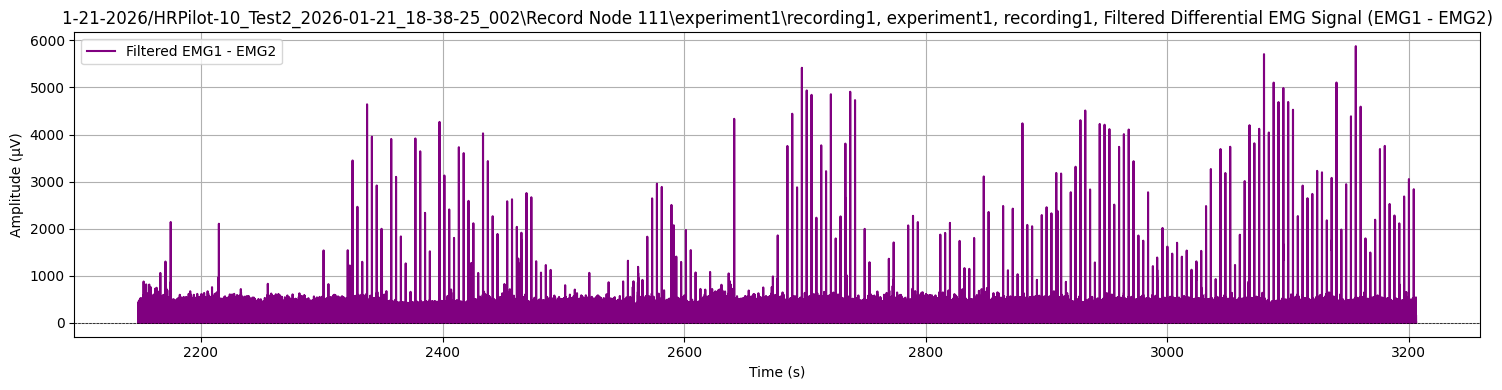

In [10]:

# Phase 1: EMG processing and full-trace plotting (protocol-aware)
from scipy.signal import butter, filtfilt, lfilter

try:
    timestamps
    data
except NameError:
    print("No recording data loaded. Please open a recording first.")
else:
    protocol = protocol_dropdown.value


    if record_node_name == "Record Node 106": #protocol == PROTOCOL_ONLINE:
        # If online filtered, the data might already be filtered on channel 3
        differential_filt = data[:, 3]
        print("Using Online Filtering: assuming channel 3 is prefiltered differential EMG")
    else:
        # Offline filtering: compute diff then apply bandpass
        
        # ==== EMG Processing ====
        emg1_raw = data[:, 2]
        emg2_raw = data[:, 3]
        differential = (emg2_raw - emg1_raw)
        lowcut = 100.0
        highcut = 1000.0
        sample_rate = globals().get('sample_rate', SAMPLE_RATE_HINT)
        b, a = butter(2, np.array([lowcut, highcut])/(sample_rate/2), btype='bandpass')
        # Use filtfilt for zero-phase filtering
        differential_filt = lfilter(b, a, differential)
        print(f"Applied offline bandpass ({lowcut}-{highcut} Hz) using lfilter at {sample_rate} Hz")

    differential_abs = np.abs(differential_filt)
    differential_emg = differential_abs

    plt.figure(figsize=(15, 4))
    plt.plot(timestamps, differential_emg, label="Filtered EMG1 - EMG2", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"{directory_str}, {experiment_name}, {recording_name}, Filtered Differential EMG Signal (EMG1 - EMG2)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# Phase 1: Segment navigation UI (view long recordings in short windows)
segment_duration = 10  # seconds
try:
    total_time = timestamps[-1] - timestamps[0]
    num_segments = int(np.ceil(total_time / segment_duration))
    current_segment = 0

    from ipywidgets import Button, VBox
    output_segment = Output()

    def plot_segment(segment_idx):
        start_time = timestamps[0] + segment_idx * segment_duration
        end_time = min(start_time + segment_duration, timestamps[-1])
        mask = (timestamps >= start_time) & (timestamps < end_time)
        plt.figure(figsize=(15, 4))
        plt.plot(timestamps[mask] - start_time, differential_emg[mask], label="Filtered EMG", color='purple')
        # show blanking regions if available
        try:
            if 'blank_mask' in globals():
                # overlay shaded regions where blank_mask is False
                blank_mask_seg = ~blank_mask[mask]
                if blank_mask_seg.any():
                    # find contiguous runs and shade
                    idxs = np.where(mask)[0]
                    runs = []
                    run_start = None
                    for local_i, global_idx in enumerate(idxs):
                        if blank_mask_seg[local_i] and run_start is None:
                            run_start = timestamps[global_idx] - start_time
                        if (not blank_mask_seg[local_i] or local_i == len(idxs)-1) and run_start is not None:
                            run_end = timestamps[global_idx] - start_time
                            runs.append((run_start, run_end))
                            run_start = None
                    for s,e in runs:
                        plt.axvspan(s, e, color='red', alpha=0.25)
        except Exception:
            pass

        plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
        # compute and show blank fraction in this segment if available
        seg_blank_frac = 0.0
        if 'blank_mask' in globals():
            try:
                seg_mask = blank_mask[mask]
                seg_blank_frac = 1.0 - (np.sum(seg_mask) / float(seg_mask.size)) if seg_mask.size>0 else 0.0
            except Exception:
                seg_blank_frac = 0.0
        plt.title(f"{directory_str}, {experiment_name}, {recording_name}, Segment {segment_idx+1}/{num_segments} | Time: {start_time:.1f}-{end_time:.1f}s | blank={seg_blank_frac:.2%}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude (μV)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def on_next(b):
        global current_segment
        if current_segment < num_segments - 1:
            current_segment += 1
            with output_segment:
                output_segment.clear_output(wait=True)
                plot_segment(current_segment)

    def on_prev(b):
        global current_segment
        if current_segment > 0:
            current_segment -= 1
            with output_segment:
                output_segment.clear_output(wait=True)
                plot_segment(current_segment)

    next_button = Button(description="Next")
    prev_button = Button(description="Previous")
    next_button.on_click(on_next)
    prev_button.on_click(on_prev)

    # Initial plot
    with output_segment:
        plot_segment(current_segment)

    display(VBox([prev_button, next_button, output_segment]))

except Exception as e:
    print("Could not set up segment navigation:", e)


In [12]:

# Phase 1: Load MessageCenter (events/messages) for stim timing and triggers
try:
    messagecenter_dir = os.path.join(directory_str.split(os.sep)[-3], record_node_name, experiment_name, recording_name, "events", "MessageCenter")
    # The above path attempt may be redundant if messagecenter already at os.path.join(directory_str, 'events', 'MessageCenter')
    if not os.path.exists(messagecenter_dir):
        # try simple: directory_str + events
        messagecenter_dir = os.path.join(directory_str, 'events', 'MessageCenter')

    if not os.path.exists(messagecenter_dir):
        print(f"MessageCenter directory not found: {messagecenter_dir}")
    else:
        texts = np.load(os.path.join(messagecenter_dir, "text.npy"), allow_pickle=True)
        timestamps_msg = np.load(os.path.join(messagecenter_dir, "timestamps.npy"))
        decoded_texts = [t.decode('utf-8') if isinstance(t, bytes) else str(t) for t in texts]
        message_entries = list(zip(timestamps_msg, decoded_texts))
        print(f"Loaded {len(decoded_texts)} MessageCenter entries from {messagecenter_dir}")
        # Debug print (first 20)
        for t, txt in message_entries[:20]:
            print(f"[Time: {t:.6f} s] Message: {txt}")

except Exception as e:
    print("MessageCenter load error:", e)


Loaded 282 MessageCenter entries from 1-21-2026/HRPilot-10_Test2_2026-01-21_18-38-25_002\Record Node 111\experiment1\recording1\events\MessageCenter
[Time: 2168.774200 s] Message: Test 2 with picoscope in. 0.25 HZ stim
[Time: 2188.238200 s] Message: Test 2 with picoscope in. 0.25 HZ stim
[Time: 2196.077400 s] Message: Starting at 0.20 mA
[Time: 2197.492400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2201.507400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2205.522600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2209.499600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2213.514800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2217.491800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2221.507000 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2225.522200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2229.499200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2232.634800 s] Message: Starting at 0.30 mA
[Time: 2233.514200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2237.491200 s] Message

# Phase 2 — Blanking, Binning and Trial Sweep

This phase implements the robust sample-based "blanking" (throw-out) around event markers and provides the trial sweep / binning pipeline for offline processing. Key design points:

- Convert trigger times to sample indices to create a binary `blank_mask` (True=valid sample, False=blanked).
- Use configurable blank window (default: 10 ms pre, 50 ms post) converted to samples via the recording's sample rate.
- Implement `compute_bin_means` and `grand_mean_from_bins` that respect the blank mask and require a `min_valid_fraction` per bin.
- Implement a `sweep_trials` function that walks through the recording, picks randomized trial durations within [TRIAL_INIT_MIN_MS, TRIAL_INIT_MAX_MS] (rounded to `BIN_DURATION_MS` multiples), and saves trials that pass the mean-amplitude acceptance criteria.

All functions are vectorized where practical and are documented in-line. The results will be saved into a `trials` list with metadata for later inspection or export.

Found 250 trigger messages
Blank mask created: 250 events -> 75250 samples blanked (0.0142 fraction)
Sweep complete. Collected 430 accepted trials.
Trial 0: start=0 end=13250 dur_ms=2650 grand_mean=44.88
Trial 1: start=13250 end=25250 dur_ms=2400 grand_mean=56.06
Trial 2: start=25250 end=38250 dur_ms=2600 grand_mean=57.85


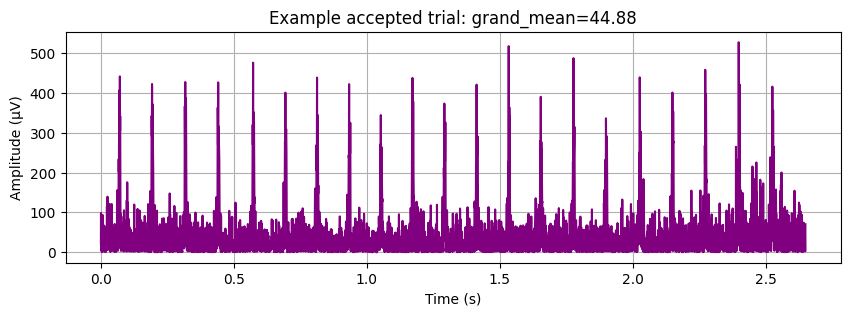

In [13]:
# Phase 2: Blanking (sample-based), binning utilities, and trial sweep
# Convert message triggers to sample indices, build a sample-accurate blank mask,
# then sweep through the recording and collect trials that meet the acceptance criteria.

# Parameters (ms)
blank_pre_ms = 10    # ms before event
blank_post_ms = 50   # ms after event
min_valid_fraction = 0.7  # require >=70% valid samples per bin


# Helper: parse trigger times from MessageCenter (RHDCONTROL TRIGGER)
trigger_pattern = re.compile(r"RHDCONTROL TRIGGER", re.IGNORECASE)
trigger_times = []
try:
    for t, msg in message_entries:
        if trigger_pattern.search(msg):
            trigger_times.append(float(t))
    trigger_times = sorted(trigger_times)
    print(f"Found {len(trigger_times)} trigger messages")
except Exception as e:
    print("No message_entries available or parsing error:", e)
    trigger_times = []

# If possible use `recording.continuous[0].metadata.sample_rate`
sample_rate = globals().get('sample_rate', SAMPLE_RATE_HINT)

# Convert trigger times to nearest sample indices
try:
    trig_sample_idxs = np.searchsorted(timestamps, np.array(trigger_times))
except Exception:
    trig_sample_idxs = np.array([], dtype=int)

# Convert ms -> samples
pre_samples = int(np.ceil(blank_pre_ms * sample_rate / 1000.0))
post_samples = int(np.ceil(blank_post_ms * sample_rate / 1000.0))

# Build blank_mask (True=keep, False=blank)
try:
    n = len(timestamps)
    blank_mask = np.ones(n, dtype=bool)
    for idx in trig_sample_idxs:
        s = max(0, int(idx - pre_samples))
        e = min(n, int(idx + post_samples) + 1)
        blank_mask[s:e] = False
    globals()['blank_mask'] = blank_mask
    print(f"Blank mask created: {len(trig_sample_idxs)} events -> {np.sum(~blank_mask)} samples blanked ({(np.sum(~blank_mask)/n):.4f} fraction)")
except Exception as e:
    print("Could not create blank mask:", e)

# Utilities for bins & trials

def compute_bin_means(signal: np.ndarray, blank_mask: np.ndarray, bin_sample_count: int):
    """Compute non-overlapping bin means and per-bin valid fraction.
    Trims excess samples at the end to keep full bins only."""
    n = len(signal)
    n_full = (n // bin_sample_count) * bin_sample_count
    if n_full == 0:
        return np.array([]), np.array([])
    sig = signal[:n_full]
    mask = blank_mask[:n_full]
    reshaped_sig = sig.reshape(-1, bin_sample_count)
    reshaped_mask = mask.reshape(-1, bin_sample_count)
    valid_counts = reshaped_mask.sum(axis=1)
    # compute means only using valid samples; invalid bins remain nan
    means = np.full((reshaped_sig.shape[0],), np.nan, dtype=np.float64)
    for i in range(reshaped_sig.shape[0]):
        if valid_counts[i] > 0:
            means[i] = reshaped_sig[i, reshaped_mask[i]].mean()
    valid_frac = valid_counts / float(bin_sample_count)
    return means, valid_frac


def grand_mean_from_bins(bin_means: np.ndarray, valid_frac: np.ndarray, min_valid_fraction: float):
    mask = (valid_frac >= min_valid_fraction) & (~np.isnan(bin_means))
    if np.sum(mask) == 0:
        return np.nan
    return float(np.mean(bin_means[mask]))


def round_to_nearest_multiple(x: int, base: int = BIN_DURATION_MS) -> int:
    return int(base * round(x / base))


# Trial sweep function: sequentially walk through recording, generate random trial durations,
# compute trial grand mean using blanking and accept trial if grand mean in initiation bounds.
from random import Random
_rng = Random(0)


def sweep_trials(signal: np.ndarray,
                 timestamps: np.ndarray,
                 blank_mask: np.ndarray,
                 sample_rate: float,
                 min_ms: int = TRIAL_INIT_MIN_MS,
                 max_ms: int = TRIAL_INIT_MAX_MS,
                 min_uv: float = TRIAL_INIT_MIN_UV,
                 max_uv: float = TRIAL_INIT_MAX_UV,
                 bin_duration_ms: int = BIN_DURATION_MS,
                 min_valid_fraction_local: float = min_valid_fraction):
    trials = []
    n = len(signal)
    i = 0
    bin_sample_count = int(np.round(bin_duration_ms * sample_rate / 1000.0))
    if bin_sample_count <= 0:
        raise ValueError('BIN_SAMPLE_COUNT computed as 0. Check sample_rate and BIN_DURATION_MS')

    while i < n:
        dur_ms = _rng.randint(min_ms, max_ms)
        dur_ms = round_to_nearest_multiple(dur_ms, base=bin_duration_ms)
        dur_samples = int(np.round(dur_ms * sample_rate / 1000.0))
        if i + dur_samples > n:
            break
        seg = signal[i:i+dur_samples]
        seg_mask = blank_mask[i:i+dur_samples]
        # compute bin stats for this candidate trial
        bin_means, valid_frac = compute_bin_means(seg, seg_mask, bin_sample_count)
        gm = grand_mean_from_bins(bin_means, valid_frac, min_valid_fraction_local)
        # Acceptance check
        if (not np.isnan(gm)) and (min_uv <= gm <= max_uv):
            trials.append({'start_sample': i,
                           'end_sample': i+dur_samples,
                           'dur_ms': dur_ms,
                           'bin_means': bin_means,
                           'valid_frac': valid_frac,
                           'grand_mean': gm})
            # advance by trial duration (non-overlapping)
            i += dur_samples
        else:
            # advance by one bin to resample starting point
            i += bin_sample_count
    return trials

# Run sweep example (be careful on big recordings)
try:
    trials = sweep_trials(differential_emg, timestamps, blank_mask, sample_rate)
    print(f"Sweep complete. Collected {len(trials)} accepted trials.")
    # Display first 3 trials summary
    for k,t in enumerate(trials[:3]):
        print(f"Trial {k}: start={t['start_sample']} end={t['end_sample']} dur_ms={t['dur_ms']} grand_mean={t['grand_mean']:.2f}")

    # Show an example accepted trial plot
    if len(trials) > 0:
        t0 = trials[0]
        s = t0['start_sample']
        e = t0['end_sample']
        plt.figure(figsize=(10,3))
        plt.plot(timestamps[s:e] - timestamps[s], differential_emg[s:e], color='purple')
        # shaded blanked regions inside trial
        blank_local = ~blank_mask[s:e]
        if blank_local.any():
            idxs = np.where(blank_local)[0]
            # find contiguous runs
            runs = []
            run_start = None
            prev_idx = None
            for pos in idxs:
                if run_start is None:
                    run_start = timestamps[s+pos] - timestamps[s]
                    prev_idx = pos
                elif pos != prev_idx + 1:
                    run_end = timestamps[s+prev_idx] - timestamps[s]
                    runs.append((run_start, run_end))
                    run_start = timestamps[s+pos] - timestamps[s]
                    prev_idx = pos
                else:
                    prev_idx = pos
            if run_start is not None:
                run_end = timestamps[s+prev_idx] - timestamps[s]
                runs.append((run_start, run_end))
            for rs,re in runs:
                plt.axvspan(rs, re, color='red', alpha=0.25)
        plt.title(f"Example accepted trial: grand_mean={t0['grand_mean']:.2f}")
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude (μV)')
        plt.grid(True)
        plt.show()

except Exception as e:
    print("Trial sweep example skipped (missing data):", e)


## Phase 2b — MH-style histogram: trial grand-means + cleaned-sample histogram 📊

This cell computes a histogram that matches the style used by `MhRecruitmentCurveStage`:

- **Primary histogram (left):** assembled *trial grand-means* (one value per accepted trial). Bins use a **1% step-size** across the primary min→max range (i.e., ~100 bins). Heights are raw **counts** (not density), and the plot includes vertical initiation-threshold lines.
- **Secondary histogram (right):** cleaned *sample-level* amplitudes (blanked samples removed) for diagnostic purposes.

Features:
- Dynamic titles/labels showing recording name, number of trials/samples, and fraction blanked. ✅
- Optional `yscale` (linear or log), and options to save PNG/JSON of histogram data.
- Exposes computed stats and arrays to the notebook namespace for downstream use (see `hist_out`, `hist_primary_stats`, etc.).

Run the histogram cell after Phase 2 to visualize the assembled binned-signal distribution and confirm initiation thresholds visually.

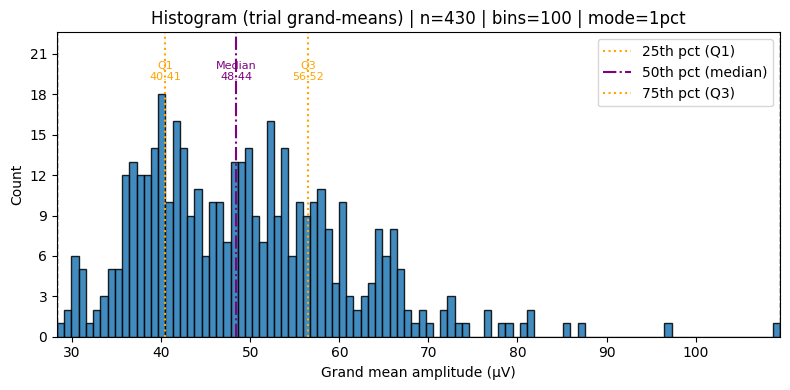

Histogram summary: n=430, min=28.298, Q1=40.414, median=48.438, Q3=56.523, max=109.476, step1%=2.093, mode=1pct


In [14]:
# Phase 2b: Histogram of trial grand-means (single panel)
import math

def compute_mh_style_histogram_and_stats(yscale='linear', save_png=False, save_json=False, num_bins=None, binning='1pct'):
    """Build an MH-style histogram of trial grand-means (single panel only).

    Returns: dict with keys: fig, ax, primary_stats, hist_vals, hist_edges, save_paths, binning
    """

    from matplotlib.ticker import MaxNLocator

    # Gather trial grand-means
    grand_means = np.array([])
    if 'trials' in globals() and len(trials) > 0:
        try:
            grand_means = np.array([float(t['grand_mean']) for t in trials])
            grand_means = grand_means[~np.isnan(grand_means)]
        except Exception:
            grand_means = np.array([])

    if grand_means.size == 0:
        print('No trial grand-means available; run sweep_trials() first.')
        fig, ax = plt.subplots(1,1,figsize=(7,4))
        ax.text(0.5,0.5,'No trial grand-means available', ha='center')
        plt.tight_layout()
        plt.show()
        primary_stats = {'n': 0}
        return {'fig': fig, 'ax': ax, 'primary_stats': primary_stats, 'hist_vals': np.array([]), 'hist_edges': np.array([]), 'save_paths': {}}

    # Compute primary stats
    mn = float(np.min(grand_means)); mx = float(np.max(grand_means)); n = int(grand_means.size)
    mean = float(np.mean(grand_means)); std_dev = float(np.std(grand_means, ddof=0))
    q25, q50, q75 = np.percentile(grand_means, [25,50,75])
    q1 = float(np.quantile(grand_means, 0.01)) if n>1 else mn
    step_one_percent = float(q1 - mn)
    if step_one_percent <= 0:
        step_one_percent = (mx - mn) / 100.0 if (mx - mn) > 0 else max(0.1, abs(mx)*0.01 if mx!=0 else 0.1)

    primary_stats = {'n': n, 'min': mn, 'max': mx, 'mean': mean, 'std_dev': std_dev, 'q25': q25, 'q50': q50, 'q75': q75, 'step_size_one_percent': step_one_percent}

    # Build histogram bins
    if binning == '1pct':
        step = step_one_percent
        edges = np.arange(mn - 0.5*step, mx + 1.5*step, step)
        if edges.size < 2:
            edges = np.linspace(mn - 0.5, mx + 0.5, 11)
        hist_vals, hist_edges = np.histogram(grand_means, bins=edges)
    elif binning == 'auto':
        hist_vals, hist_edges = np.histogram(grand_means, bins='auto')
    else:
        bins = 100 if num_bins is None else int(num_bins)
        hist_vals, hist_edges = np.histogram(grand_means, bins=bins)

    # ✅ Enforce minimum bins here
    if hist_vals.size < 100:
        hist_vals, hist_edges = np.histogram(
            grand_means,
            bins=100,
            range=(mn, mx)
        )

    # Plot single panel
    fig, ax = plt.subplots(1,1, figsize=(8,4))
    centers = (hist_edges[:-1] + hist_edges[1:]) / 2.0
    widths = (hist_edges[1:] - hist_edges[:-1])
    ax.bar(centers, hist_vals, width=widths, align='center', color='C0', edgecolor='k', alpha=0.85)
    ax.set_xlabel('Grand mean amplitude (μV)')
    ax.set_ylabel('Count')
    ax.set_title(f'Histogram (trial grand-means) | n={n:,} | bins={len(hist_vals)} | mode={binning}')

    
    
    ax.set_xlim(hist_edges[0], hist_edges[-1])
    #ax.set_xlim(11, 15) #Uncomment this line here to manually set bounds of histogram
    ax.axvline(mn, color='black', linestyle='--', linewidth=1.0, label='_nolegend_')
    ax.axvline(mx, color='black', linestyle='--', linewidth=1.0, label='_nolegend_')
    if 'TRIAL_INIT_MIN_UV' in globals():
        ax.axvline(TRIAL_INIT_MIN_UV, color='red', linestyle='--', linewidth=1.5, label='_nolegend_')
        ax.axvline(TRIAL_INIT_MAX_UV, color='red', linestyle='--', linewidth=1.5, label='_nolegend_')

    # Quartile lines and labels (Q1, median, Q3)
    try:
        ymax_est = int(max(hist_vals)) if hist_vals.size>0 else 1
        y_text = ymax_est * 1.05
        ax.axvline(q25, color='orange', linestyle=':', linewidth=1.5, label='25th pct (Q1)')
        ax.axvline(q50, color='purple', linestyle='-.', linewidth=1.5, label='50th pct (median)')
        ax.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label='75th pct (Q3)')
        ax.text(q25, y_text, f'Q1\n{q25:.2f}', color='orange', ha='center', va='bottom', fontsize=8)
        ax.text(q50, y_text, f'Median\n{q50:.2f}', color='purple', ha='center', va='bottom', fontsize=8)
        ax.text(q75, y_text, f'Q3\n{q75:.2f}', color='orange', ha='center', va='bottom', fontsize=8)
    except Exception:
        pass

    ax.legend()

    ymax = int(max(hist_vals)) if hist_vals.size>0 else 1
    ax.set_ylim(0, ymax*1.2 + 1)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    if yscale in ('log','symlog'):
        ax.set_yscale(yscale)

    plt.tight_layout()
    plt.show()

    # Save if requested (primary histogram only)
    save_paths = {}
    if save_png and 'directory_str' in globals() and 'recording_name' in globals():
        try:
            png_path = os.path.join(directory_str, f"{recording_name}_grandmeans_histogram.png")
            fig.savefig(png_path, dpi=150)
            save_paths['png'] = png_path
        except Exception as e:
            print('Could not save histogram PNG:', e)
    if save_json and hist_vals.size > 0 and 'directory_str' in globals() and 'recording_name' in globals():
        try:
            json_path = os.path.join(directory_str, f"{recording_name}_grandmeans_histogram.json")
            hist_dict = {'hist_vals': hist_vals.tolist(), 'hist_edges': hist_edges.tolist(), 'primary_stats': primary_stats, 'binning': binning}
            with open(json_path, 'w') as jf:
                json.dump(hist_dict, jf, indent=2)
            save_paths['json'] = json_path
        except Exception as e:
            print('Could not save histogram JSON:', e)

    print(
    f"Histogram summary: "
    f"n={n}, "
    f"min={mn:.3f}, "
    f"Q1={q25:.3f}, "
    f"median={q50:.3f}, "
    f"Q3={q75:.3f}, "
    f"max={mx:.3f}, "
    f"step1%={step_one_percent:.3f}, "
    f"mode={binning}" 
    )


    return {'fig': fig, 'ax': ax, 'primary_stats': primary_stats, 'hist_vals': hist_vals, 'hist_edges': hist_edges, 'save_paths': save_paths, 'binning': binning}


# Run updated histogram and store outputs (primary grand-means only)
hist_out = compute_mh_style_histogram_and_stats(yscale='linear')
# Expose fields to globals for downstream usage (primary only)
globals().update({
    'hist_primary_stats': hist_out.get('primary_stats', {}),
    'hist_values': hist_out.get('hist_vals', np.array([])),
    'hist_edges': hist_out.get('hist_edges', np.array([])),
})


### Phase 3 — Peri-stimulus extraction, grouping, and M/H detection 





# Peri‑stimulus viewer (what this section does)

This section builds stimulation amplitude groups from the previously-extracted peri-stimulus windows and provides an interactive, paged viewer:

- Shows groups in **2x2 pages** with individual traces (faint) and the group average (bold), shaded stimulus duration, M/H windows, and annotated peaks.
- Double-click a subplot (if your frontend/backend supports it) to open a full-size zoomed view of that group.
- Use the **View** dropdown + button to reliably open a zoomed view if click events are not supported.
- While zoomed you can **Save PNG** for quick export, or return to the grid with **Back to grid**.

Troubleshooting & tips:
- If you get no groups, verify `MessageCenter` parsing and that `peri_stim_segments` was populated by the detection cell.
- Some Jupyter frontends do not support Matplotlib click events in inline mode — use the dropdown+View button in that case.
- If saving fails, check that `directory_str` and `recording_name` are available (they're set when you open a recording).


In [15]:
# Phase 3: Peri-stimulus viewer (2x2 paged, zoomable, saveable)

from ipywidgets import Button, Output, HBox, VBox, Dropdown, Label


# ==== Peri-Stimulus Analysis with Shaded Stimulus Duration ====
pre_event_time = 5   # ms before calculated stim start
post_event_time = 20 # ms after calculated stim start
stim_threshold = 0.01 # ADC1 threshold to detect pulse (adjust if needed)
offstim_threshold = .41


m_wave_start, m_wave_end = 1.5, 4
h_wave_start, h_wave_end = 4.5, 10



peri_stim_segments = []
peri_stim_segments_adc1 = []
segment_stim_end_times = []
segment_stim_start_times = []

# ==== Sync Setup ====

differential_emg = differential_filt


# ==== Load ADC1 (for stim detection) ====
adc1 = np.abs(data[:, 4])  # adjust if your ADC1 channel index differs

# ==== Sync Events ====
events = recording.events
sync_events = events[(events.line == 1) & (events.processor_id == 100) &
                        (events.stream_name == 'Rhythm Data') & (events.state == 1)]
sync_timestamps = sync_events['timestamp'].to_numpy()


print(recording)

for stamp in sync_timestamps:
        # First, find approximate sample index around the sync pulse
        #idx_start = np.searchsorted(timestamps, stamp)
        #idx_end   = np.searchsorted(timestamps, stamp + 0.010)
        #idx_center = (idx_start + idx_end)/2

        idx_search_start = np.searchsorted(timestamps, stamp - 0.00003)  # 10 ms before sync
        idx_search_end   = np.searchsorted(timestamps, stamp + 0.010)  # 10 ms after sync

        if idx_search_start < 0 or idx_search_end > len(timestamps):
            continue

        adc1_segment_for_detection = adc1[idx_search_start:idx_search_end]
        time_segment_for_detection = timestamps[idx_search_start:idx_search_end]

        # Detect true stim start: first crossing above threshold in that window
        above_idxs = np.where(adc1_segment_for_detection > stim_threshold)[0]
        
        if len(above_idxs) == 0:
            continue
        stim_start_idx = idx_search_start + above_idxs[0]
        stim_start_time = timestamps[stim_start_idx]

        # Now define peri-stimulus window around this stim_start_time
        idx_pre  = int(stim_start_idx - (pre_event_time / 1000) * sample_rate)
        idx_post = int(stim_start_idx + (post_event_time / 1000) * sample_rate)

        if idx_pre < 0 or idx_post > len(timestamps):
            continue

        # Extract windows
        time_window = timestamps[idx_pre:idx_post]
        time_zeroed = time_window - stim_start_time  # in seconds

        emg_window  = differential_emg[idx_pre:idx_post]
        adc1_window = adc1[idx_pre:idx_post]

        # Detect stim end: first time after stim_start where ADC1 falls back below threshold
        post_onset_mask = (time_zeroed >= 0)
        adc1_post_onset = adc1_window[post_onset_mask]
        time_post_onset = time_zeroed[post_onset_mask]

        below_idxs = np.where(adc1_post_onset < offstim_threshold)[0]
        if len(below_idxs) > 0:
            stim_end_time = time_post_onset[below_idxs[0]] * 1000  # convert to ms
        else:
            stim_end_time = post_event_time

        # Save for grouping
        peri_stim_segments.append((time_zeroed * 1000, emg_window, stim_end_time))
        peri_stim_segments_adc1.append(adc1_window)
        segment_stim_start_times.append(stim_start_time)
        segment_stim_end_times.append(stim_end_time)

#print(time_window)
#print(idx_search_start)
#print(idx_search_end)
#print(peri_stim_segments_adc1)
#print(peri_stim_segments)
print(stim_end_time)


# ==== Dynamically determine stimulation groups based on event messages ====

# First, extract only trigger messages and stim setting messages
trigger_pattern = re.compile(r"RHDCONTROL TRIGGER")
stim_pattern = re.compile(r"starting(?: at)? (\d+\.?\d*)\s*mA", re.IGNORECASE)

stim_groups = []
current_group = []
current_amp = None
trigger_times = []

for t, msg in message_entries:
    if stim_pattern.search(msg):
        # Save the previous group if any
        if current_amp is not None and current_group:
            stim_groups.append((current_amp, current_group))
        # Start new group
        current_amp = float(stim_pattern.search(msg).group(1))
        current_group = []
    elif trigger_pattern.search(msg):
        if current_amp is not None:
            current_group.append(t)

# Don't forget to save the last group
if current_amp is not None and current_group:
    stim_groups.append((current_amp, current_group))


# ==== Match trigger times to peri_stim_segments ====
# Create dictionary to associate each stim amplitude to its segments
stim_intensities = []
m_wave_peaks = []
h_wave_peaks = []




# Build consolidated groups list (amp + traces + averages)
groups_list = []
for stim_amp, trigger_times_group in stim_groups:
    group_data = []
    group_adc1 = []
    for trig_time in trigger_times_group:
        if len(segment_stim_start_times) == 0:
            continue
        idx_match = np.argmin(np.abs(np.array(segment_stim_start_times) - trig_time))
        if abs(segment_stim_start_times[idx_match] - trig_time) < 0.1:
            group_data.append(peri_stim_segments[idx_match])
            group_adc1.append(peri_stim_segments_adc1[idx_match])
    if not group_data:
        continue
    time_ms_matrix = np.stack([gd[0] for gd in group_data])
    emg_matrix     = np.stack([gd[1] for gd in group_data])
    avg_time_ms = time_ms_matrix[0]
    avg_emg = np.mean(emg_matrix, axis=0)
    avg_adc1 = np.mean(group_adc1, axis=0) if len(group_adc1)>0 else None
    avg_end_ms = np.mean([gd[2] for gd in group_data])
    stim_intensities.append(stim_amp)
    traces = [gd[1] for gd in group_data]
    groups_list.append({'amp': stim_amp,
                        'time_ms': avg_time_ms,
                        'avg_emg': avg_emg,
                        'traces': traces,
                        'avg_adc1': avg_adc1,
                        'avg_end_ms': avg_end_ms})
    m_wave_mask = (avg_time_ms >= m_wave_start) & (avg_time_ms <= m_wave_end)
    m_wave_time_window = avg_time_ms[m_wave_mask]
    m_wave_emg_window = avg_emg[m_wave_mask]
    m_wave_peak_idx = np.argmax(m_wave_emg_window)
    m_wave_peak_time = m_wave_time_window[m_wave_peak_idx]
    m_wave_peak_amp = m_wave_emg_window[m_wave_peak_idx]
    m_wave_peaks.append(m_wave_peak_amp)

    h_wave_mask = (avg_time_ms >= h_wave_start) & (avg_time_ms <= h_wave_end)
    h_wave_time_window = avg_time_ms[h_wave_mask]
    h_wave_emg_window = avg_emg[h_wave_mask]
    h_wave_peak_idx = np.argmax(h_wave_emg_window)
    h_wave_peak_time = h_wave_time_window[h_wave_peak_idx]
    h_wave_peak_amp = h_wave_emg_window[h_wave_peak_idx]
    h_wave_peaks.append(h_wave_peak_amp)

if len(groups_list) == 0:
    print('No valid stimulation groups found to display. Check that peri-stimulus extraction (Phase 3 earlier cells) populated `peri_stim_segments` and that `MessageCenter` groups were found.')
else:
    # Pagination setup
    n_per_page = 4
    pages = [groups_list[i:i+n_per_page] for i in range(0, len(groups_list), n_per_page)]
    current_page = {'idx': 0}

    print(f'Prepared {len(groups_list)} stimulation groups across {len(pages)} pages. Use the controls to page through groups.')

    out = Output()

    # Dropdown used to select which subplot on the current page to zoom
    amp_dropdown = Dropdown(options=[], description='View:')
    zoom_button = Button(description='View', button_style='info')

    # Keep track of active mpl connection so we can disconnect when re-rendering
    active_conn = {'cid': None, 'canvas': None}

    def show_zoom(group):
        # Display a full-size single-plot view for the selected group
        with out:
            out.clear_output(wait=True)
            import matplotlib.pyplot as plt
            fig, ax = plt.subplots(1, 1, figsize=(8, 5))
            t = group['time_ms']
            for tr in group['traces']:
                ax.plot(t, tr, color='red', alpha=0.4)
            ax.plot(t, group['avg_emg'], color='black', linewidth=2, label='Average')
            ax.axvspan(0, group['avg_end_ms'], color='red', alpha=0.25)
            ax.axvspan(m_wave_start, m_wave_end, color='blue', alpha=0.2)
            ax.axvspan(h_wave_start, h_wave_end, color='green', alpha=0.2)
            # peaks
            m_mask = (t >= m_wave_start) & (t <= m_wave_end)
            if np.any(m_mask):
                m_win = group['avg_emg'][m_mask]
                m_twin = t[m_mask]
                if m_win.size>0:
                    m_idx = np.argmax(m_win)
                    m_time = m_twin[m_idx]
                    m_amp  = m_win[m_idx]
                    ax.axvline(m_time, color='blue', linestyle=':', linewidth=1.5)
                    ax.text(m_time, m_amp + 0.05*np.max(group['avg_emg']), f'{m_amp:.1f} μV', color='blue', ha='center', fontsize=9)
            h_mask = (t >= h_wave_start) & (t <= h_wave_end)
            if np.any(h_mask):
                h_win = group['avg_emg'][h_mask]
                h_twin = t[h_mask]
                if h_win.size>0:
                    h_idx = np.argmax(h_win)
                    h_time = h_twin[h_idx]
                    h_amp  = h_win[h_idx]
                    ax.axvline(h_time, color='green', linestyle=':', linewidth=1.5)
                    ax.text(h_time, h_amp + 0.05*np.max(group['avg_emg']), f'{h_amp:.1f} μV', color='green', ha='center', fontsize=9)

            ax.set_title(f"Stim Amp: {group['amp']:.2f} mA | n={len(group['traces'])}")
            ax.set_xlabel('Time (ms)')
            ax.set_ylabel('Amplitude (μV)')
            ax.xaxis.set_major_locator(MultipleLocator(1))     # major ticks every 2 ms
            ax.xaxis.set_minor_locator(MultipleLocator(0.5))   # minor ticks every 0.5 ms
            ax.grid(True, which='both', alpha=0.3)

            plt.tight_layout()
            plt.show()

            # Back and Save controls
            back_button = Button(description='Back to grid', button_style='info')
            save_button = Button(description='Save PNG', button_style='success')

            def on_back(b):
                plot_page(current_page['idx'])
            back_button.on_click(on_back)

            def on_save(b):
                try:
                    save_dir = globals().get('directory_str', os.getcwd())
                    fname = f"{globals().get('recording_name','recording')}_zoom_{group['amp']:.2f}mA.png"
                    fullp = os.path.join(save_dir, fname)
                    fig.savefig(fullp, dpi=150)
                    print(f"Saved zoom PNG to: {fullp}")
                except Exception as e:
                    print('Could not save PNG:', e)

            save_button.on_click(on_save)
            display(HBox([back_button, save_button]))

    def plot_page(page_idx):
        # Disconnect previous mpl connection if any
        try:
            if active_conn['cid'] is not None and active_conn['canvas'] is not None:
                try:
                    active_conn['canvas'].mpl_disconnect(active_conn['cid'])
                except Exception:
                    pass
                active_conn['cid'] = None
                active_conn['canvas'] = None
        except Exception:
            pass

        with out:
            out.clear_output(wait=True)
            page = pages[page_idx]
            n = len(page)
            import matplotlib.pyplot as plt
            fig, axs = plt.subplots(2, 2, figsize=(12, 8))
            axs = axs.flatten()

            # Populate amp dropdown for this page
            amp_dropdown.options = [(f"{g['amp']:.2f} mA", idx) for idx, g in enumerate(page)]
            if amp_dropdown.options:
                amp_dropdown.value = 0

            for j in range(4):
                ax = axs[j]
                if j < n:
                    g = page[j]
                    t = g['time_ms']
                    # individual traces
                    for tr in g['traces']:
                        ax.plot(t, tr, color='red', alpha=0.4)
                    # average
                    ax.plot(t, g['avg_emg'], color='black', linewidth=2, label='Average')
                    # shade stimulus region
                    stim_end = g['avg_end_ms']
                    ax.axvspan(0, stim_end, color='red', alpha=0.25)
                    # M/H windows
                    ax.axvspan(m_wave_start, m_wave_end, color='blue', alpha=0.2)
                    ax.axvspan(h_wave_start, h_wave_end, color='green', alpha=0.2)
                    # find and plot peaks (if valid)
                    m_mask = (t >= m_wave_start) & (t <= m_wave_end)
                    if np.any(m_mask):
                        m_win = g['avg_emg'][m_mask]
                        m_twin = t[m_mask]
                        if m_win.size>0:
                            m_idx = np.argmax(m_win)
                            m_time = m_twin[m_idx]
                            m_amp  = m_win[m_idx]
                            ax.axvline(m_time, color='blue', linestyle=':', linewidth=1.5)
                            ax.text(m_time, m_amp + 0.05*np.max(g['avg_emg']), f'{m_amp:.1f} μV', color='blue', ha='center', fontsize=8)
                    h_mask = (t >= h_wave_start) & (t <= h_wave_end)
                    if np.any(h_mask):
                        h_win = g['avg_emg'][h_mask]
                        h_twin = t[h_mask]
                        if h_win.size>0:
                            h_idx = np.argmax(h_win)
                            h_time = h_twin[h_idx]
                            h_amp  = h_win[h_idx]
                            ax.axvline(h_time, color='green', linestyle=':', linewidth=1.5)
                            ax.text(h_time, h_amp + 0.05*np.max(g['avg_emg']), f'{h_amp:.1f} μV', color='green', ha='center', fontsize=8)

                    ax.set_title(f"Stim Amp:{g['amp']:.2f} mA | n={len(g['traces'])}")
                    ax.set_xlabel('Time (ms)')
                    ax.set_ylabel('Amplitude (μV)')
                    ax.xaxis.set_major_locator(MultipleLocator(1))     # major ticks every 2 ms
                    ax.xaxis.set_minor_locator(MultipleLocator(0.5))   # minor ticks every 0.5 ms
                    ax.grid(True, which='both', alpha=0.3)
                    ax.grid(True)
                    try:
                        ax.set_xlim(left=np.min(t), right=np.max(t))
                    except Exception:
                        pass
                else:
                    ax.axis('off')

            plt.tight_layout()
            plt.show()

            # Try to attach click/double-click handler (some backends may not support it)
            try:
                def on_mpl_click(event):
                    # Only respond if click is inside an axis shown
                    if event.inaxes is None:
                        return
                    # find which subplot was clicked
                    for k, ax in enumerate(axs):
                        if event.inaxes == ax:
                            # double click zooms (may not be available in some frontends)
                            if getattr(event, 'dblclick', False):
                                show_zoom(page[k])
                            else:
                                # single click selects the subplot in dropdown for manual zoom
                                amp_dropdown.value = k
                            break
                cid = fig.canvas.mpl_connect('button_press_event', on_mpl_click)
                active_conn['cid'] = cid
                active_conn['canvas'] = fig.canvas
            except Exception:
                # interactive clicks may not be available; user can use the dropdown+Zoom button
                print('Click-to-zoom not available in this backend. Use the "View" button or dropdown to select a subplot.')

    def on_next(b):
        if current_page['idx'] < len(pages) - 1:
            current_page['idx'] += 1
            plot_page(current_page['idx'])

    def on_prev(b):
        if current_page['idx'] > 0:
            current_page['idx'] -= 1
            plot_page(current_page['idx'])

    def on_dropdown_change(change):
        # Respond to page dropdown changes (value -> new page index)
        if 'new' in change:
            current_page['idx'] = change['new']
            plot_page(current_page['idx'])

    def on_zoom_click(b):
        # Zoom the selected item in the current page
        sel = amp_dropdown.value
        try:
            sel_idx = int(sel)
            page = pages[current_page['idx']]
            if 0 <= sel_idx < len(page):
                show_zoom(page[sel_idx])
        except Exception:
            print('Could not zoom selected group. Check dropdown selection.')

    next_button = Button(description='Next', button_style='primary')
    prev_button = Button(description='Previous')
    page_dropdown = Dropdown(options=[(f'Page {i+1}', i) for i in range(len(pages))], description='Page:')

    next_button.on_click(on_next)
    prev_button.on_click(on_prev)
    page_dropdown.observe(on_dropdown_change)
    zoom_button.on_click(on_zoom_click)

    controls = HBox([prev_button, next_button, page_dropdown, Label(' '), amp_dropdown, zoom_button])

    # Initial render
    display(VBox([controls, out]))
    plot_page(0)

Open Ephys GUI Recording
ID: 0x273d3529090
Format: Binary
Directory: 1-21-2026/HRPilot-10_Test2_2026-01-21_18-38-25_002\Record Node 111\experiment1\recording1
Experiment Index: 0
Recording Index: 0
0.4000000008090865
Prepared 30 stimulation groups across 8 pages. Use the controls to page through groups.


## Phase 4 — Recruitment normalization and saving results

In this phase we normalize the M-wave amplitudes to M_max and compute the current corresponding to 50% M_max (interpolation). We also annotate H_max and the corresponding current. Results (trials and amplitude summaries) can be exported for downstream analysis.

In [16]:
# Phase 4: Normalize recruitment curves and save results
from scipy.interpolate import interp1d
import json

if 'amp_results' not in globals() or len(amp_results)==0:
    print("No amplitude results available to normalize.")
else:
    amps_sorted = sorted(amp_results.keys())
    m_means = np.array([amp_results[a]['m_amp'] for a in amps_sorted])
    h_means = np.array([amp_results[a]['h_amp'] for a in amps_sorted])
    # Use absolute values
    m_means_abs = np.abs(m_means)
    h_means_abs = np.abs(h_means)

    M_max = np.max(m_means_abs)
    if M_max == 0:
        print("M_max is zero; cannot normalize.")
    else:
        m_norm = (m_means_abs / M_max) * 100.0
        h_norm = (h_means_abs / M_max) * 100.0

        # Interpolate to find current at 50% Mmax
        try:
            interp_func = interp1d(m_norm, amps_sorted, kind='linear', bounds_error=False, fill_value='extrapolate')
            current_at_50 = float(interp_func(50.0))
        except Exception:
            current_at_50 = np.nan

        H_max = np.nanmax(h_norm)
        idx_Hmax = int(np.nanargmax(h_norm)) if not np.all(np.isnan(h_norm)) else None
        current_at_Hmax_norm = (amps_sorted[idx_Hmax] / current_at_50) if (idx_Hmax is not None and not np.isnan(current_at_50) and current_at_50 != 0) else np.nan

        # Plot normalized curves
        plt.figure(figsize=(8,4))
        plt.plot(np.array(amps_sorted)/current_at_50, m_norm, 'o-', color='blue', label='M (% Mmax)')
        plt.plot(np.array(amps_sorted)/current_at_50, h_norm, 's-', color='green', label='H (% Mmax)')
        plt.axhline(H_max, color='green', linestyle='--', label=f'H_max = {H_max:.1f}%')
        if not np.isnan(current_at_Hmax_norm):
            plt.axvline(current_at_Hmax_norm, color='gray', linestyle='--', label=f'Current at H_max = {current_at_Hmax_norm:.2f}x')
        plt.xlabel('Current (Normalized to Current at 50% Mmax)')
        plt.ylabel('% of Mmax')
        plt.title('Normalized Recruitment Curves')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Save results
        results = {
            'amps_sorted': amps_sorted,
            'm_means_abs': m_means_abs.tolist(),
            'h_means_abs': h_means_abs.tolist(),
            'm_norm': m_norm.tolist(),
            'h_norm': h_norm.tolist(),
            'M_max': float(M_max),
            'H_max': float(H_max),
            'current_at_50': float(current_at_50)
        }

#        save_path = os.path.join(DEFAULT_DATA_DIR, f"recruitment_summary_{experiment_name}_{recording_name}.json")
#        try:
#            with open(save_path, 'w') as f:
#               json.dump(results, f, indent=2)
#            print(f"Saved recruitment summary to {save_path}")
#        except Exception as e:
#            print("Could not save recruitment summary:", e)''

No amplitude results available to normalize.


C:\Users\yahri\AppData\Local\Temp\ipykernel_22616\3080696344.py:18: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  m_sems  = np.array([stats.sem(peaks) for peaks in m_wave_data])
C:\Users\yahri\AppData\Local\Temp\ipykernel_22616\3080696344.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  h_sems  = np.array([stats.sem(peaks) for peaks in h_wave_data])


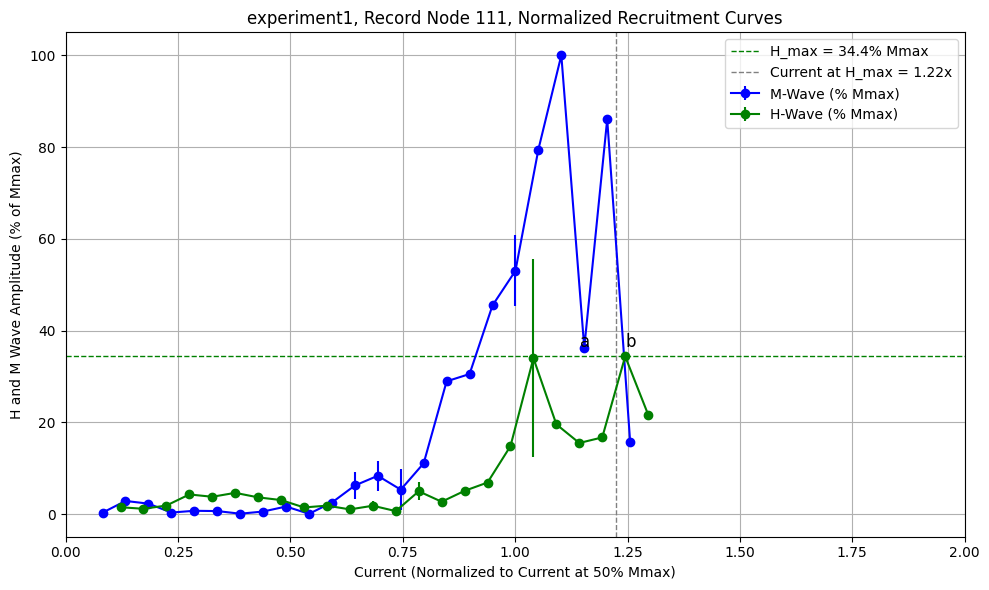

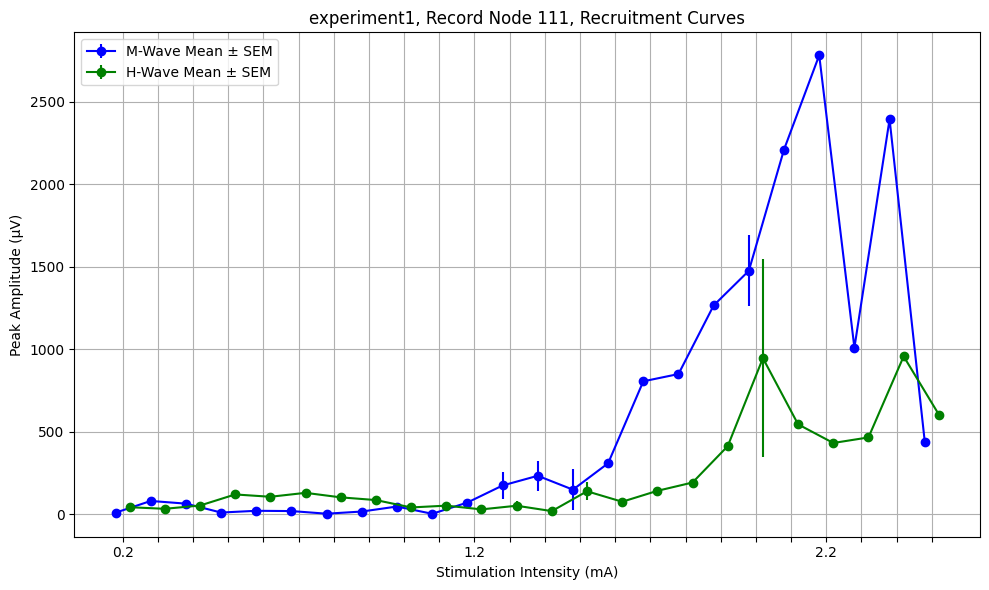

In [17]:
# ==== Group and Normalize Peak Amplitudes ====
m_wave_dict = defaultdict(list)
h_wave_dict = defaultdict(list)

# Ensure all amplitudes are absolute values
for amp, m_peak, h_peak in zip(stim_intensities, m_wave_peaks, h_wave_peaks):
    m_wave_dict[amp].append(abs(m_peak))
    h_wave_dict[amp].append(abs(h_peak))

# Sort stimulation intensities
sorted_amps = sorted(set(stim_intensities))
m_wave_data = [m_wave_dict[amp] for amp in sorted_amps]
h_wave_data = [h_wave_dict[amp] for amp in sorted_amps]

# Compute means
m_means = np.array([np.mean(peaks) for peaks in m_wave_data])
h_means = np.array([np.mean(peaks) for peaks in h_wave_data])
m_sems  = np.array([stats.sem(peaks) for peaks in m_wave_data])
h_sems  = np.array([stats.sem(peaks) for peaks in h_wave_data])

# Find M_max and normalize amplitudes
M_max = np.max(m_means)
m_means_norm = (m_means / M_max) * 100
h_means_norm = (h_means / M_max) * 100
m_sems_norm  = (m_sems  / M_max) * 100
h_sems_norm  = (h_sems  / M_max) * 100

# Interpolate M-curve to find current at 50% M_max
from scipy.interpolate import interp1d

interp_func = interp1d(m_means_norm, sorted_amps, kind='linear', bounds_error=False, fill_value='extrapolate')
try:
    current_at_50_percent = float(interp_func(50))
except:
    current_at_50_percent = sorted_amps[np.argmax(m_means_norm >= 50)]

# Normalize current axis
normalized_currents = np.array(sorted_amps) / current_at_50_percent

# Mark H_max (point "a") and Current at H_max (point "b")
H_max = np.max(h_means_norm)
idx_Hmax = np.argmax(h_means_norm)
current_at_Hmax_norm = normalized_currents[idx_Hmax]

# ==== Plot Normalized Recruitment Curves ====
fig, ax = plt.subplots(figsize=(10, 6))

# Overlay normalized mean ± SEM
ax.errorbar(normalized_currents - 0.02, m_means_norm, yerr=m_sems_norm, fmt='o-', color='blue', label='M-Wave (% Mmax)')
ax.errorbar(normalized_currents + 0.02, h_means_norm, yerr=h_sems_norm, fmt='o-', color='green', label='H-Wave (% Mmax)')

# Add point "a" (H_max) and "b" (Current at H_max)
ax.axhline(H_max, color='green', linestyle='--', linewidth=1, label=f'H_max = {H_max:.1f}% Mmax')
ax.axvline(current_at_Hmax_norm, color='gray', linestyle='--', linewidth=1, label=f'Current at H_max = {current_at_Hmax_norm:.2f}x')

# Add labels
ax.text(current_at_Hmax_norm + 0.02, H_max + 2, 'b', fontsize=12, color='black')
ax.text(normalized_currents[idx_Hmax] - 0.08, H_max + 2, 'a', fontsize=12, color='black')

# Aesthetics
#ax.set_xticks(np.round(normalized_currents, 2))
#ax.set_xticklabels([f"{x:.2f}" for x in normalized_currents])
ax.set_xlabel("Current (Normalized to Current at 50% Mmax)")
ax.set_ylabel("H and M Wave Amplitude (% of Mmax)")
ax.set_title(f"{experiment_name}, {record_node_name}, Normalized Recruitment Curves")
ax.grid(True)
ax.legend()
# Set window size here
ax.set_xlim(right=2)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()



# ==== Plot Recruitment Curves as Box-and-Whisker ====
fig, ax = plt.subplots(figsize=(10, 6))



# Boxplots
positions = np.arange(len(sorted_amps))  # for spacing

#Overlay mean ± SEM
ax.errorbar(positions - 0.2, m_means, yerr=m_sems, fmt='o-', color='blue', label='M-Wave Mean ± SEM')
ax.errorbar(positions + 0.2, h_means, yerr=h_sems, fmt='o-', color='green', label='H-Wave Mean ± SEM')

# Aesthetics
ax.set_xticks(positions)
tick_labels = []
for i, amp in enumerate(sorted_amps):
    if i % 10 == 0:  # show every 10th label
        tick_labels.append(f"{amp:.1f}")
    else:
        tick_labels.append("")  # leave blank

ax.set_xticklabels(tick_labels)

#ax.set_xticklabels([f"{amp:.1f}" for amp in sorted_amps])
ax.set_xlabel("Stimulation Intensity (mA)")
ax.set_ylabel("Peak Amplitude (μV)")
ax.set_title(f"{experiment_name}, {record_node_name}, Recruitment Curves")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()



# Phase 5: Trial Initiation Simulation — Comprehensive Overview

## 🎯 **Objective**

This phase simulates the **real-time trial initialization process** used in the `Mh_recruitment_curve_stage.py` module but operates offline on recorded data. The goal is to:

1. **Replicate the state machine logic** that decides when to initiate a trial based on EMG activity
2. **Process the original (un-blanked) EMG signal** using a sliding window and binning approach
3. **Count total trial attempts and successful trial initiations**
4. **Analyze success rates and timing statistics**

---

## 📋 **How the Trial Initialization System Works**

The MH Recruitment Curve stage uses a sophisticated state machine to determine optimal moments for electrical stimulation. This ensures stimuli are delivered during stable, quiet EMG periods rather than during muscle activation or noise.

### **Key Design Principles**

| Component | Description | Purpose |
|-----------|-------------|---------|
| **Sliding Monitoring Window** | Random duration 2200–2700 ms (rounded to 50 ms) | Prevents subject anticipation |
| **50 ms Bins** | Signal divided into 250-sample bins (at 5 kHz) | Smooths transient artifacts |
| **Grand Mean Threshold** | Mean of all bin means must fall within min/max bounds | Ensures baseline stability |
| **Inter-Trial Interval** | Minimum 10 seconds between trials | Prevents overstimulation |
| **State Machine** | NOT_SETUP → WAIT_FOR_INITIATION → RECORD → FINALIZE | Structured trial flow |

---

## 🔄 **State Machine Architecture**

```
┌─────────────────┐
│   NOT_SETUP     │ → Initialize new trial parameters
└────────┬────────┘   (random monitoring duration, thresholds)
         │
         ▼
┌─────────────────┐
│ WAIT_FOR_INIT   │ → Continuously monitor EMG
└────────┬────────┘   Process incoming data blocks
         │            Check: window full? Mean in range?
         │
         ▼
  ┌─────────────┐
  │ Initiation? │────No─→ Continue monitoring
  └──────┬──────┘
         │ Yes
         ▼
┌─────────────────┐
│     RECORD      │ → Save pre+post stimulus EMG
└────────┬────────┘   (50 ms pre + 100 ms post)
         │
         ▼
┌─────────────────┐
│    FINALIZE     │ → Log trial, compute stats
└────────┬────────┘   Return to NOT_SETUP
         │
         └──────────→ Loop for next trial
```

---

## 🧮 **Trial Initiation Algorithm (Pseudocode)**

```python
# Setup phase (once per trial attempt)
monitoring_duration_ms = random(2200, 2700)  # randomized
monitoring_duration_ms = round_to_50ms(monitoring_duration_ms)
monitored_signal_buffer = []
bins = []
samples_needed = monitoring_duration_ms * sample_rate / 1000

# Continuous processing (simulates streaming data)
for each data_block in recording:
    append data_block to monitored_signal_buffer
    keep only most recent 'samples_needed' samples
    
    # Bin the monitoring window
    for each 50ms bin:
        bins[i] = mean(monitored_signal_buffer[bin_range])
    
    # Compute grand mean
    grand_mean = mean(bins)
    
    # Check initiation criteria
    if buffer_full AND grand_mean in [min_threshold, max_threshold]:
        if time_since_last_trial >= 10 seconds:
            INITIATE TRIAL
            state = RECORD
    else:
        continue monitoring
```

---

## 📊 **What This Phase Outputs**

After running the simulation, you'll see:

✅ **Total trial attempts**: How many times the system tried to initiate  
✅ **Successful trials**: How many met all criteria (window full, thresholds, inter-trial interval)  
✅ **Success rate**: Percentage of successful initiations  
✅ **Inter-trial intervals**: Distribution of time between successful trials  
✅ **Grand mean distribution**: Histogram of accepted trial grand means  
✅ **Timeline visualization**: When trials occurred during the recording  

---

## 🛠 **Implementation Notes**

- **Uses original (un-blanked) EMG data**: This simulates the real-time system which doesn't know about future stimulus events
- **Block-based processing**: Data is processed in chunks to mimic real-time streaming (default: 50 samples ~10 ms at 5 kHz)
- **Configurable thresholds**: You can adjust `SIMULATION_MIN_INIT_UV` and `SIMULATION_MAX_INIT_UV` to explore different acceptance criteria
- **Reproducible**: Uses a seeded random number generator for consistent results

---

## 📦 **Required Data from Previous Phases**

This phase requires:
- ✅ `differential_emg` (absolute rectified EMG signal)
- ✅ `timestamps` (sample timestamps)
- ✅ `sample_rate` (e.g., 5000 Hz)
- ✅ Phase 2 histogram stats (optional, for informed threshold selection)

---

**Ready to proceed?** Run the cells below to execute the trial initiation simulation and analyze the results.

## Phase 5a: Configuration and Helper Classes

This cell defines the simulation parameters and implements the core `TrialInitiationData` class that replicates the logic from `mh_recruitment_curve_stage.py`.

In [26]:
# Phase 5a: Simulation Configuration and Trial Initiation Data Class

from random import Random
from dataclasses import dataclass, field
from typing import List, Optional
import time

# ====================================================================
# SIMULATION PARAMETERS
# ====================================================================

# These parameters control the trial initiation simulation
# Adjust these to match your Phase 2 histogram statistics

# Initiation thresholds (in μV) - Set based on your histogram from Phase 2
# Recommendation: Use values from hist_primary_stats (e.g., Q1 and Q3)
SIMULATION_MIN_INIT_UV = 5  # Lower bound for acceptable EMG
SIMULATION_MAX_INIT_UV = 300 # Upper bound for acceptable EMG

# Trial monitoring window duration (milliseconds)
TRIAL_INIT_MIN_DURATION_MS = 2200  # Minimum monitoring window
TRIAL_INIT_MAX_DURATION_MS = 2700  # Maximum monitoring window

# Binning parameters
BIN_DURATION_MS_SIM = 50  # Each bin represents 50 ms of data
# BIN_SAMPLE_COUNT will be computed from sample_rate

# Inter-trial interval constraint
MINIMUM_INTERTRIAL_INTERVAL_MS = 10000  # 10 seconds minimum between trials

# Trial recording duration (post-initiation)
TRIAL_RECORDING_DURATION_MS = 100  # Record 100 ms after initiation

# Simulation processing parameters
SIMULATION_BLOCK_SIZE = 50  # Process data in chunks of 50 samples (~10 ms at 5 kHz)
                            # This simulates real-time streaming behavior

# Random seed for reproducibility
SIMULATION_RANDOM_SEED = 42

print("=" * 70)
print("PHASE 5 SIMULATION CONFIGURATION")
print("=" * 70)
print(f"Initiation Thresholds: {SIMULATION_MIN_INIT_UV:.1f} - {SIMULATION_MAX_INIT_UV:.1f} μV")
print(f"Monitoring Window: {TRIAL_INIT_MIN_DURATION_MS} - {TRIAL_INIT_MAX_DURATION_MS} ms")
print(f"Bin Duration: {BIN_DURATION_MS_SIM} ms")
print(f"Min Inter-Trial Interval: {MINIMUM_INTERTRIAL_INTERVAL_MS} ms ({MINIMUM_INTERTRIAL_INTERVAL_MS/1000:.1f} s)")
print(f"Simulation Block Size: {SIMULATION_BLOCK_SIZE} samples")
print(f"Random Seed: {SIMULATION_RANDOM_SEED}")
print("=" * 70)


# ====================================================================
# HELPER CLASSES
# ====================================================================

@dataclass
class SimulatedTrial:
    """Represents a single simulated trial with all relevant metadata."""
    trial_number: int
    start_sample_idx: int
    start_time: float  # in seconds
    monitoring_duration_ms: int
    grand_mean_uv: float
    min_threshold: float
    max_threshold: float
    bin_means: np.ndarray
    pre_stim_data: np.ndarray  # 50 ms pre-stimulus data
    post_stim_data: np.ndarray  # 100 ms post-stimulus data
    time_since_last_trial_ms: Optional[float] = None


class TrialInitiationData:
    """
    Replicates the trial initiation logic from MhRecruitmentCurveStage_TrialInitiationData.
    
    This class maintains a sliding monitoring window of EMG data, bins it into 50 ms segments,
    and determines whether the current EMG state meets the criteria for trial initiation.
    
    Key responsibilities:
    - Maintain a rolling buffer of monitored EMG samples
    - Divide the buffer into bins and compute bin means
    - Calculate the grand mean (mean of bin means)
    - Determine if initiation criteria are met
    """
    
    def __init__(self, sample_rate: float):
        """
        Initialize the trial initiation data structure.
        
        Args:
            sample_rate: Sampling rate in Hz (e.g., 5000)
        """
        self.sample_rate = sample_rate
        self.bin_sample_count = int((sample_rate / 1000.0) * BIN_DURATION_MS_SIM)
        
        # State variables
        self.monitored_signal_abs: np.ndarray = np.array([])
        self.bins: np.ndarray = np.array([])
        self.monitored_signal_duration_seconds: float = 0.0
        self.monitored_signal_sample_count: int = 0
        self.current_monitored_signal_sample_count: int = 0
        
    def initialize(self, duration_ms: int) -> None:
        """
        Initialize the monitoring window for a new trial attempt.
        
        Args:
            duration_ms: Monitoring duration in milliseconds (should be rounded to 50 ms)
        """
        # Convert to seconds
        self.monitored_signal_duration_seconds = float(duration_ms) / 1000.0
        
        # Set the number of samples we need to monitor
        self.monitored_signal_sample_count = int(
            self.monitored_signal_duration_seconds * self.sample_rate
        )
        
        # Calculate number of bins
        bin_count = int(duration_ms / BIN_DURATION_MS_SIM)
        
        # Initialize arrays
        self.monitored_signal_abs = np.zeros(self.monitored_signal_sample_count)
        self.bins = np.zeros(bin_count)
        self.current_monitored_signal_sample_count = 0
        
    def process(self, 
                data_block_abs: np.ndarray, 
                current_min_threshold: float, 
                current_max_threshold: float) -> tuple[bool, float]:
        """
        Process a new block of absolute EMG data and determine if trial should initiate.
        
        This method:
        1. Appends new data to the monitored signal buffer
        2. Keeps only the most recent samples (sliding window)
        3. Bins the data into 50 ms segments
        4. Computes the grand mean of all bins
        5. Checks if initiation criteria are met
        
        Args:
            data_block_abs: New absolute EMG samples to process
            current_min_threshold: Minimum acceptable grand mean (μV)
            current_max_threshold: Maximum acceptable grand mean (μV)
            
        Returns:
            Tuple of (should_initiate: bool, grand_mean: float)
        """
        should_initiate = False
        
        # Update sample count
        self.current_monitored_signal_sample_count += len(data_block_abs)
        
        # Append new data to monitored signal
        self.monitored_signal_abs = np.concatenate([self.monitored_signal_abs, data_block_abs])
        
        # Keep only the most recent samples (sliding window)
        elements_to_remove = len(self.monitored_signal_abs) - self.monitored_signal_sample_count
        if elements_to_remove > 0:
            self.monitored_signal_abs = self.monitored_signal_abs[elements_to_remove:]
        
        # Bin the data
        for bin_idx in range(len(self.bins)):
            bin_start = self.bin_sample_count * bin_idx
            bin_end = self.bin_sample_count * (bin_idx + 1)
            
            # Handle edge case where bin extends beyond available data
            if bin_end > len(self.monitored_signal_abs):
                bin_end = len(self.monitored_signal_abs)
            
            if bin_end > bin_start:  # Ensure we have data in this bin
                bin_mean = np.mean(self.monitored_signal_abs[bin_start:bin_end])
                self.bins[bin_idx] = bin_mean
        
        # Calculate grand mean (mean of all bins)
        bin_grand_mean = np.mean(self.bins)
        
        # Check initiation criteria
        if (self.current_monitored_signal_sample_count >= self.monitored_signal_sample_count and
            bin_grand_mean >= current_min_threshold and
            bin_grand_mean <= current_max_threshold):
            should_initiate = True
        
        return should_initiate, bin_grand_mean
    
    def get_current_buffer(self) -> np.ndarray:
        """Return the current monitored signal buffer."""
        return self.monitored_signal_abs.copy()
    
    def get_bin_means(self) -> np.ndarray:
        """Return the current bin means."""
        return self.bins.copy()


def round_to_nearest_50ms(value_ms: int) -> int:
    """Round a value in milliseconds to the nearest 50 ms increment."""
    return 50 * round(value_ms / 50)


print("\n✅ Helper classes and functions defined successfully.")
print(f"   - SimulatedTrial dataclass")
print(f"   - TrialInitiationData class (replicates mh_recruitment_curve_stage.py logic)")
print(f"   - Utility functions (round_to_nearest_50ms)")
print(f"\n   Bin sample count (at {globals().get('sample_rate', 5000)} Hz): "
      f"{int((globals().get('sample_rate', 5000) / 1000.0) * BIN_DURATION_MS_SIM)} samples/bin")

PHASE 5 SIMULATION CONFIGURATION
Initiation Thresholds: 5.0 - 300.0 μV
Monitoring Window: 2200 - 2700 ms
Bin Duration: 50 ms
Min Inter-Trial Interval: 10000 ms (10.0 s)
Simulation Block Size: 50 samples
Random Seed: 42

✅ Helper classes and functions defined successfully.
   - SimulatedTrial dataclass
   - TrialInitiationData class (replicates mh_recruitment_curve_stage.py logic)
   - Utility functions (round_to_nearest_50ms)

   Bin sample count (at 5000.0 Hz): 250 samples/bin


## Phase 5b: Main Simulation Engine — State Machine Implementation

This cell contains the core simulation loop that processes the recorded EMG data using a state machine to simulate real-time trial initialization.

In [27]:
# Phase 5b: Main Simulation Engine with State Machine

# Define state constants (matching mh_recruitment_curve_stage.py)
STATE_NOT_SETUP = 0
STATE_WAIT_FOR_INITIATION = 1
STATE_RECORD = 2
STATE_FINALIZE = 3

STATE_NAMES = {
    STATE_NOT_SETUP: "NOT_SETUP",
    STATE_WAIT_FOR_INITIATION: "WAIT_FOR_INITIATION",
    STATE_RECORD: "RECORD",
    STATE_FINALIZE: "FINALIZE"
}


def run_trial_initiation_simulation(
    emg_signal: np.ndarray,
    timestamps: np.ndarray,
    sample_rate: float,
    min_init_threshold: float = SIMULATION_MIN_INIT_UV,
    max_init_threshold: float = SIMULATION_MAX_INIT_UV,
    block_size: int = SIMULATION_BLOCK_SIZE,
    min_inter_trial_ms: int = MINIMUM_INTERTRIAL_INTERVAL_MS,
    verbose: bool = True,
    max_trials: int = None
) -> tuple[List[SimulatedTrial], dict]:
    """
    Simulate the trial initiation process by processing EMG data with a state machine.
    
    This function replicates the behavior of MhRecruitmentCurveStage.process() by:
    1. Processing data in blocks (simulating real-time streaming)
    2. Using a state machine (NOT_SETUP -> WAIT_FOR_INITIATION -> RECORD -> FINALIZE)
    3. Enforcing inter-trial intervals
    4. Recording trials that meet initiation criteria
    
    Args:
        emg_signal: Absolute rectified EMG signal (1D array)
        timestamps: Corresponding timestamps in seconds
        sample_rate: Sampling rate in Hz
        min_init_threshold: Minimum acceptable grand mean (μV)
        max_init_threshold: Maximum acceptable grand mean (μV)
        block_size: Number of samples to process per iteration (simulates streaming)
        min_inter_trial_ms: Minimum time between trials in milliseconds
        verbose: Print progress messages
        max_trials: Maximum number of trials to simulate (None = unlimited)
        
    Returns:
        Tuple of (successful_trials: List[SimulatedTrial], statistics: dict)
    """
    
    # Initialize random number generator for reproducible results
    rng = Random(SIMULATION_RANDOM_SEED)
    
    # Initialize state
    current_state = STATE_NOT_SETUP
    trial_initiation_data = None
    current_trial_number = 0
    successful_trials = []
    
    # Tracking variables
    current_sample_idx = 0
    total_samples = len(emg_signal)
    last_trial_time_ms = -min_inter_trial_ms  # Allow first trial immediately
    recording_start_idx = 0
    pre_stim_sample_count = int((sample_rate / 1000.0) * BIN_DURATION_MS_SIM)  # 50 ms
    post_stim_sample_count = int((sample_rate / 1000.0) * TRIAL_RECORDING_DURATION_MS)  # 100 ms
    
    # Statistics
    total_monitoring_attempts = 0
    total_threshold_checks = 0
    threshold_passed_count = 0
    inter_trial_blocks_count = 0
    
    # Progress tracking
    start_time = time.time()
    last_progress_pct = 0
    
    if verbose:
        print("=" * 80)
        print("STARTING TRIAL INITIATION SIMULATION")
        print("=" * 80)
        print(f"Total samples to process: {total_samples:,}")
        print(f"Recording duration: {timestamps[-1] - timestamps[0]:.2f} seconds")
        print(f"Processing block size: {block_size} samples ({block_size/sample_rate*1000:.1f} ms)")
        print(f"Thresholds: {min_init_threshold:.1f} - {max_init_threshold:.1f} μV")
        print(f"Min inter-trial interval: {min_inter_trial_ms} ms")
        print("=" * 80)
        print()
    
    # Main simulation loop - process data in blocks
    while current_sample_idx < total_samples:
        
        # Extract current data block
        block_end_idx = min(current_sample_idx + block_size, total_samples)
        data_block = emg_signal[current_sample_idx:block_end_idx]
        block_timestamps = timestamps[current_sample_idx:block_end_idx]
        current_time_ms = block_timestamps[0] * 1000  # Convert to ms
        
        # Progress reporting
        if verbose:
            progress_pct = int((current_sample_idx / total_samples) * 100)
            if progress_pct >= last_progress_pct + 10:  # Report every 10%
                elapsed = time.time() - start_time
                print(f"Progress: {progress_pct}% | Trials: {len(successful_trials)} | "
                      f"State: {STATE_NAMES[current_state]} | "
                      f"Elapsed: {elapsed:.1f}s")
                last_progress_pct = progress_pct
        
        # ============================================================
        # STATE MACHINE
        # ============================================================
        
        if current_state == STATE_NOT_SETUP:
            # Initialize a new trial attempt
            total_monitoring_attempts += 1
            
            # Choose random monitoring duration (rounded to 50 ms)
            monitoring_duration_ms = rng.randint(
                TRIAL_INIT_MIN_DURATION_MS,
                TRIAL_INIT_MAX_DURATION_MS
            )
            monitoring_duration_ms = round_to_nearest_50ms(monitoring_duration_ms)
            
            # Create and initialize trial initiation data
            trial_initiation_data = TrialInitiationData(sample_rate)
            trial_initiation_data.initialize(monitoring_duration_ms)
            
            # Transition to waiting state
            current_state = STATE_WAIT_FOR_INITIATION
            
            if verbose and len(successful_trials) < 5:  # Verbose for first few trials
                print(f"\n[Trial Attempt #{total_monitoring_attempts}] "
                      f"Monitoring window: {monitoring_duration_ms} ms")
        
        elif current_state == STATE_WAIT_FOR_INITIATION:
            # Check inter-trial interval constraint
            time_since_last_trial_ms = current_time_ms - last_trial_time_ms
            
            if time_since_last_trial_ms < min_inter_trial_ms:
                # Still in inter-trial timeout period
                inter_trial_blocks_count += 1
                current_sample_idx = block_end_idx
                continue
            
            # Process the current data block
            should_initiate, grand_mean = trial_initiation_data.process(
                data_block,
                min_init_threshold,
                max_init_threshold
            )
            
            total_threshold_checks += 1
            
            if should_initiate:
                # Trial initiation criteria met!
                threshold_passed_count += 1
                current_trial_number += 1
                
                # Transition to RECORD state
                current_state = STATE_RECORD
                recording_start_idx = current_sample_idx
                last_trial_time_ms = current_time_ms
                
                # Store metadata for this trial
                current_trial_metadata = {
                    'trial_number': current_trial_number,
                    'start_sample_idx': current_sample_idx,
                    'start_time': block_timestamps[0],
                    'monitoring_duration_ms': monitoring_duration_ms,
                    'grand_mean_uv': grand_mean,
                    'min_threshold': min_init_threshold,
                    'max_threshold': max_init_threshold,
                    'bin_means': trial_initiation_data.get_bin_means(),
                    'time_since_last_trial_ms': time_since_last_trial_ms
                }
                
                if verbose and current_trial_number <= 5:
                    print(f"  ✓ TRIAL INITIATED! Grand mean: {grand_mean:.2f} μV | "
                          f"Time: {block_timestamps[0]:.2f}s")
        
        elif current_state == STATE_RECORD:
            # Record post-stimulus data (we already have pre-stim from monitoring buffer)
            samples_recorded = current_sample_idx - recording_start_idx
            samples_needed = pre_stim_sample_count + post_stim_sample_count
            
            if samples_recorded >= samples_needed:
                # We have enough data, move to finalize
                current_state = STATE_FINALIZE
            
        elif current_state == STATE_FINALIZE:
            # Extract pre and post stimulus data
            pre_start = max(0, recording_start_idx - pre_stim_sample_count)
            pre_end = recording_start_idx
            post_start = recording_start_idx
            post_end = min(recording_start_idx + post_stim_sample_count, total_samples)
            
            pre_stim_data = emg_signal[pre_start:pre_end]
            post_stim_data = emg_signal[post_start:post_end]
            
            # Create trial object
            trial = SimulatedTrial(
                **current_trial_metadata,
                pre_stim_data=pre_stim_data,
                post_stim_data=post_stim_data
            )
            
            successful_trials.append(trial)
            
            if verbose and current_trial_number <= 5:
                print(f"  → Trial #{current_trial_number} finalized.\n")
            
            # Return to setup for next trial
            current_state = STATE_NOT_SETUP
            trial_initiation_data = None
            
            # Check if we've reached max trials
            if max_trials is not None and len(successful_trials) >= max_trials:
                if verbose:
                    print(f"\nReached maximum trial count ({max_trials}). Stopping simulation.")
                break
        
        # Advance to next block
        current_sample_idx = block_end_idx
    
    # ============================================================
    # SIMULATION COMPLETE - COMPUTE STATISTICS
    # ============================================================
    
    elapsed_time = time.time() - start_time
    
    # Compute inter-trial intervals
    inter_trial_intervals = []
    if len(successful_trials) > 1:
        for i in range(1, len(successful_trials)):
            isi = (successful_trials[i].start_time - successful_trials[i-1].start_time) * 1000  # ms
            inter_trial_intervals.append(isi)
    
    statistics = {
        'total_samples_processed': current_sample_idx,
        'total_monitoring_attempts': total_monitoring_attempts,
        'total_threshold_checks': total_threshold_checks,
        'threshold_passed_count': threshold_passed_count,
        'successful_trials': len(successful_trials),
        'inter_trial_blocks_count': inter_trial_blocks_count,
        'success_rate_pct': (len(successful_trials) / total_monitoring_attempts * 100) 
                            if total_monitoring_attempts > 0 else 0,
        'inter_trial_intervals_ms': inter_trial_intervals,
        'mean_inter_trial_interval_ms': np.mean(inter_trial_intervals) if inter_trial_intervals else 0,
        'elapsed_time_seconds': elapsed_time,
        'processing_speed_samples_per_sec': current_sample_idx / elapsed_time if elapsed_time > 0 else 0
    }
    
    if verbose:
        print("\n" + "=" * 80)
        print("SIMULATION COMPLETE")
        print("=" * 80)
        print(f"✓ Processed {current_sample_idx:,} samples in {elapsed_time:.2f} seconds")
        print(f"✓ Total monitoring attempts: {total_monitoring_attempts}")
        print(f"✓ Successful trials: {len(successful_trials)}")
        print(f"✓ Success rate: {statistics['success_rate_pct']:.1f}%")
        if inter_trial_intervals:
            print(f"✓ Mean inter-trial interval: {statistics['mean_inter_trial_interval_ms']:.1f} ms")
        print("=" * 80)
        print()
    
    return successful_trials, statistics


# ====================================================================
# RUN THE SIMULATION
# ====================================================================

print("🚀 Preparing to run simulation...")
print()

# Verify required data is available
try:
    assert 'differential_emg' in globals(), "differential_emg not found! Run Phase 1 first."
    assert 'timestamps' in globals(), "timestamps not found! Run Phase 1 first."
    assert 'sample_rate' in globals(), "sample_rate not found! Run Phase 1 first."
    
    print(f"✓ EMG signal loaded: {len(differential_emg):,} samples")
    print(f"✓ Timestamps loaded: {len(timestamps):,} samples")
    print(f"✓ Sample rate: {sample_rate} Hz")
    print()
    
    # Run the simulation
    simulated_trials, sim_statistics = run_trial_initiation_simulation(
        emg_signal=differential_emg,
        timestamps=timestamps,
        sample_rate=sample_rate,
        min_init_threshold=SIMULATION_MIN_INIT_UV,
        max_init_threshold=SIMULATION_MAX_INIT_UV,
        block_size=SIMULATION_BLOCK_SIZE,
        min_inter_trial_ms=MINIMUM_INTERTRIAL_INTERVAL_MS,
        verbose=True,
        max_trials=None  # Set to a number to limit trials (e.g., 50)
    )
    
    # Store results in global scope for downstream analysis
    globals()['simulated_trials'] = simulated_trials
    globals()['sim_statistics'] = sim_statistics
    
    print("✅ Simulation results stored in 'simulated_trials' and 'sim_statistics' variables.")
    
except AssertionError as e:
    print(f"❌ Error: {e}")
except Exception as e:
    print(f"❌ Unexpected error during simulation: {e}")
    import traceback
    traceback.print_exc()

🚀 Preparing to run simulation...

✓ EMG signal loaded: 5,289,722 samples
✓ Timestamps loaded: 5,289,722 samples
✓ Sample rate: 5000.0 Hz

STARTING TRIAL INITIATION SIMULATION
Total samples to process: 5,289,722
Recording duration: 1057.94 seconds
Processing block size: 50 samples (10.0 ms)
Thresholds: 5.0 - 300.0 μV
Min inter-trial interval: 10000 ms


[Trial Attempt #1] Monitoring window: 2550 ms
Progress: 10% | Trials: 0 | State: WAIT_FOR_INITIATION | Elapsed: 2.7s
Progress: 20% | Trials: 0 | State: WAIT_FOR_INITIATION | Elapsed: 5.4s
Progress: 30% | Trials: 0 | State: WAIT_FOR_INITIATION | Elapsed: 8.2s
Progress: 40% | Trials: 0 | State: WAIT_FOR_INITIATION | Elapsed: 11.0s
Progress: 50% | Trials: 0 | State: WAIT_FOR_INITIATION | Elapsed: 13.7s
Progress: 60% | Trials: 0 | State: WAIT_FOR_INITIATION | Elapsed: 16.7s
Progress: 70% | Trials: 0 | State: WAIT_FOR_INITIATION | Elapsed: 19.5s
Progress: 80% | Trials: 0 | State: WAIT_FOR_INITIATION | Elapsed: 22.4s
Progress: 90% | Trials: 0 

## Phase 5c: Results Analysis and Visualization

Now that the simulation is complete, let's analyze the results with comprehensive statistics and visualizations.

PHASE 5 SIMULATION RESULTS — DETAILED ANALYSIS

📊 SUMMARY STATISTICS
--------------------------------------------------------------------------------
Total Monitoring Attempts:     1
Successful Trial Initiations:  0
Success Rate:                  0.00%

Recording Duration:            1057.94 seconds
Total Samples Processed:       5,289,722
Simulation Time:               27.82 seconds
Processing Speed:              190,124 samples/sec

--------------------------------------------------------------------------------

🔍 FIRST 10 TRIALS (Detailed View)
--------------------------------------------------------------------------------
#     Time (s)     Grand Mean      Monitor (ms)    ISI (ms)    
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------

📈 GENERATING VISUALIZATIONS...



c:\Users\yahri\AppData\Roaming\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\yahri\AppData\Roaming\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


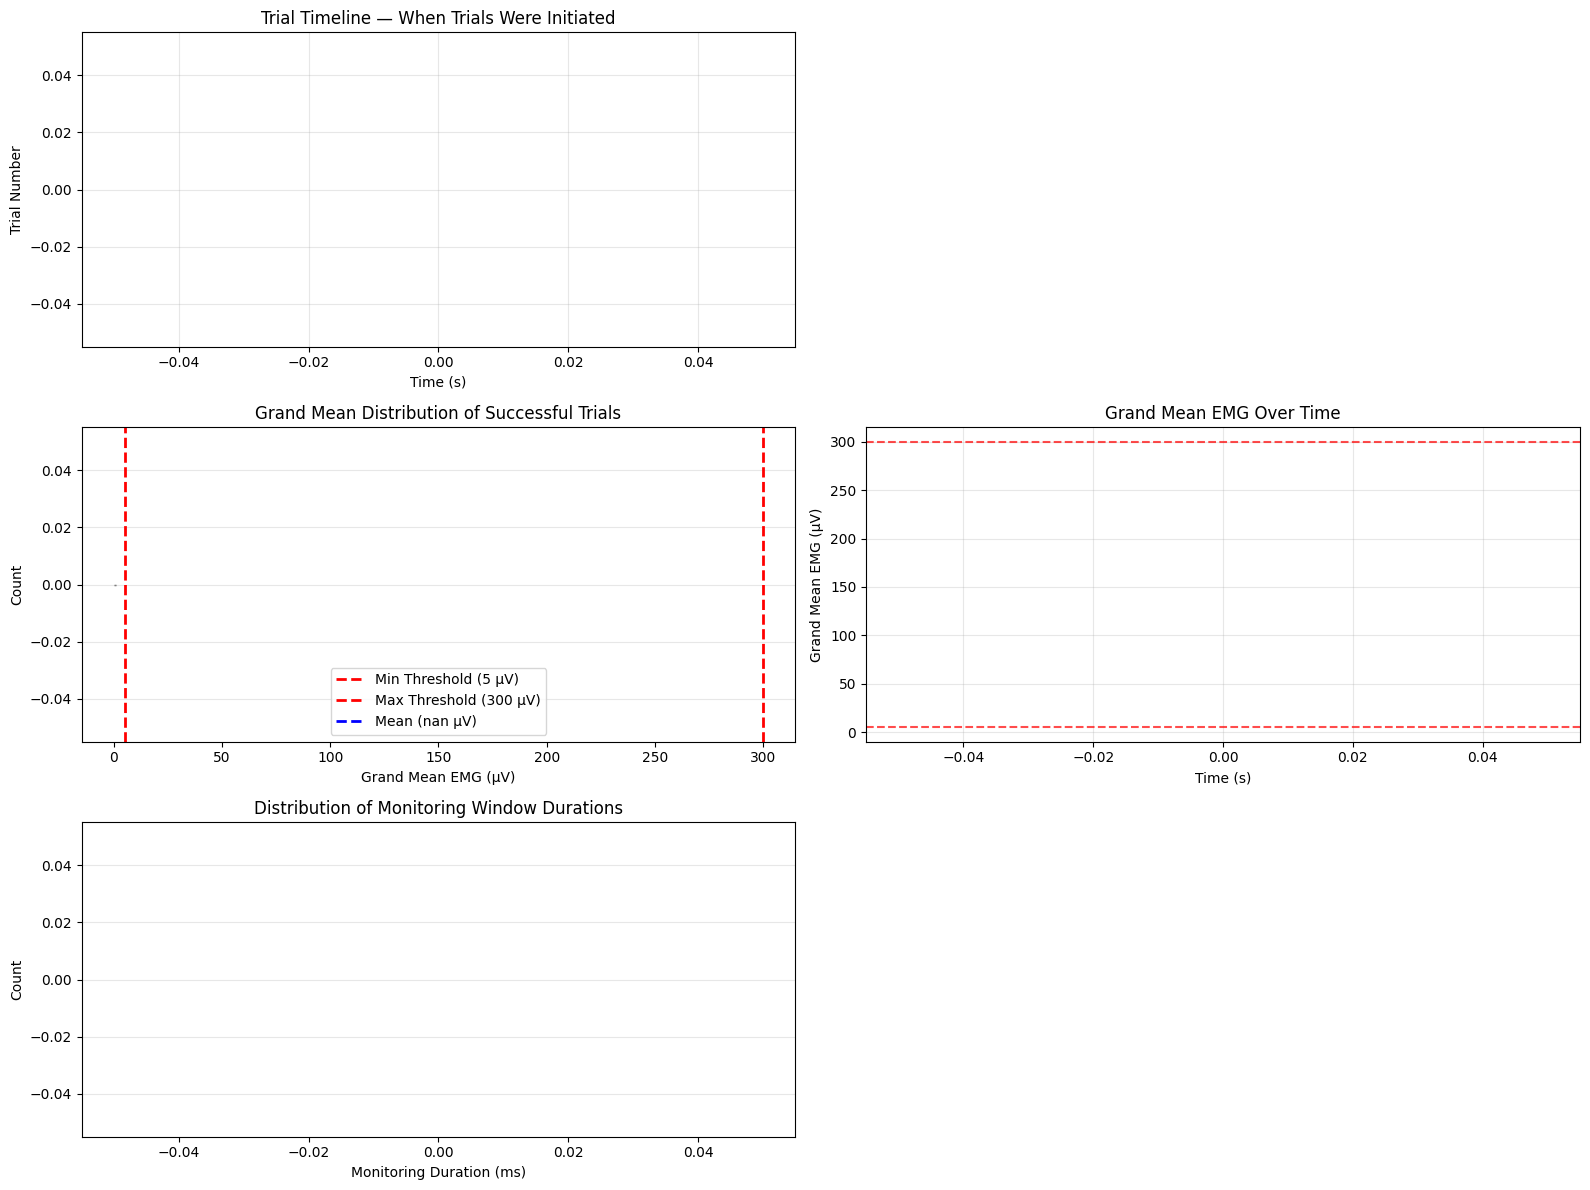

✅ Visualizations generated successfully.

ANALYSIS COMPLETE


In [28]:
# Phase 5c: Detailed Results Analysis and Visualization

if 'simulated_trials' not in globals() or 'sim_statistics' not in globals():
    print("❌ No simulation results found. Please run Phase 5b first.")
else:
    print("=" * 80)
    print("PHASE 5 SIMULATION RESULTS — DETAILED ANALYSIS")
    print("=" * 80)
    print()
    
    # ================================================================
    # SECTION 1: Summary Statistics
    # ================================================================
    print("📊 SUMMARY STATISTICS")
    print("-" * 80)
    print(f"Total Monitoring Attempts:     {sim_statistics['total_monitoring_attempts']:,}")
    print(f"Successful Trial Initiations:  {sim_statistics['successful_trials']:,}")
    print(f"Success Rate:                  {sim_statistics['success_rate_pct']:.2f}%")
    print()
    print(f"Recording Duration:            {timestamps[-1] - timestamps[0]:.2f} seconds")
    print(f"Total Samples Processed:       {sim_statistics['total_samples_processed']:,}")
    print(f"Simulation Time:               {sim_statistics['elapsed_time_seconds']:.2f} seconds")
    print(f"Processing Speed:              {sim_statistics['processing_speed_samples_per_sec']:,.0f} samples/sec")
    print()
    
    if len(simulated_trials) > 1:
        # Trial timing statistics
        inter_trial_intervals = sim_statistics['inter_trial_intervals_ms']
        print(f"Inter-Trial Interval Stats (ms):")
        print(f"  Mean:                        {np.mean(inter_trial_intervals):,.1f} ms")
        print(f"  Median:                      {np.median(inter_trial_intervals):,.1f} ms")
        print(f"  Std Dev:                     {np.std(inter_trial_intervals):,.1f} ms")
        print(f"  Min:                         {np.min(inter_trial_intervals):,.1f} ms")
        print(f"  Max:                         {np.max(inter_trial_intervals):,.1f} ms")
        print()
        
        # Grand mean statistics
        grand_means = [t.grand_mean_uv for t in simulated_trials]
        print(f"Grand Mean EMG Stats (μV):")
        print(f"  Mean:                        {np.mean(grand_means):.2f} μV")
        print(f"  Median:                      {np.median(grand_means):.2f} μV")
        print(f"  Std Dev:                     {np.std(grand_means):.2f} μV")
        print(f"  Min:                         {np.min(grand_means):.2f} μV")
        print(f"  Max:                         {np.max(grand_means):.2f} μV")
        print()
        
        # Monitoring duration statistics
        mon_durations = [t.monitoring_duration_ms for t in simulated_trials]
        print(f"Monitoring Duration Stats (ms):")
        print(f"  Mean:                        {np.mean(mon_durations):.1f} ms")
        print(f"  Min:                         {np.min(mon_durations):.1f} ms")
        print(f"  Max:                         {np.max(mon_durations):.1f} ms")
        print()
    
    print("-" * 80)
    print()
    
    # ================================================================
    # SECTION 2: First Few Trials Detail
    # ================================================================
    print("🔍 FIRST 10 TRIALS (Detailed View)")
    print("-" * 80)
    print(f"{'#':<5} {'Time (s)':<12} {'Grand Mean':<15} {'Monitor (ms)':<15} {'ISI (ms)':<12}")
    print("-" * 80)
    
    for i, trial in enumerate(simulated_trials[:10]):
        isi_str = f"{trial.time_since_last_trial_ms:.1f}" if trial.time_since_last_trial_ms is not None else "N/A"
        print(f"{trial.trial_number:<5} "
              f"{trial.start_time:<12.2f} "
              f"{trial.grand_mean_uv:<15.2f} "
              f"{trial.monitoring_duration_ms:<15} "
              f"{isi_str:<12}")
    
    if len(simulated_trials) > 10:
        print(f"... and {len(simulated_trials) - 10} more trials")
    
    print("-" * 80)
    print()
    
    # ================================================================
    # SECTION 3: Visualization
    # ================================================================
    print("📈 GENERATING VISUALIZATIONS...")
    print()
    
    # Create a comprehensive multi-panel figure
    fig = plt.figure(figsize=(16, 12))
    
    # -------------------- Panel 1: Trial Timeline --------------------
    ax1 = plt.subplot(3, 2, 1)
    trial_times = [t.start_time for t in simulated_trials]
    trial_numbers = [t.trial_number for t in simulated_trials]
    ax1.plot(trial_times, trial_numbers, 'o-', markersize=4, linewidth=1)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Trial Number')
    ax1.set_title('Trial Timeline — When Trials Were Initiated')
    ax1.grid(True, alpha=0.3)
    
    # -------------------- Panel 2: Inter-Trial Intervals --------------------
    if len(simulated_trials) > 1:
        ax2 = plt.subplot(3, 2, 2)
        inter_trial_intervals = sim_statistics['inter_trial_intervals_ms']
        ax2.hist(inter_trial_intervals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        ax2.axvline(MINIMUM_INTERTRIAL_INTERVAL_MS, color='red', linestyle='--', 
                    linewidth=2, label=f'Min ITI ({MINIMUM_INTERTRIAL_INTERVAL_MS} ms)')
        ax2.axvline(np.mean(inter_trial_intervals), color='green', linestyle='--', 
                    linewidth=2, label=f'Mean ({np.mean(inter_trial_intervals):.1f} ms)')
        ax2.set_xlabel('Inter-Trial Interval (ms)')
        ax2.set_ylabel('Count')
        ax2.set_title('Inter-Trial Interval Distribution')
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
    
    # -------------------- Panel 3: Grand Mean Distribution --------------------
    ax3 = plt.subplot(3, 2, 3)
    grand_means = [t.grand_mean_uv for t in simulated_trials]
    ax3.hist(grand_means, bins=40, edgecolor='black', alpha=0.7, color='orange')
    ax3.axvline(SIMULATION_MIN_INIT_UV, color='red', linestyle='--', 
                linewidth=2, label=f'Min Threshold ({SIMULATION_MIN_INIT_UV} μV)')
    ax3.axvline(SIMULATION_MAX_INIT_UV, color='red', linestyle='--', 
                linewidth=2, label=f'Max Threshold ({SIMULATION_MAX_INIT_UV} μV)')
    ax3.axvline(np.mean(grand_means), color='blue', linestyle='--', 
                linewidth=2, label=f'Mean ({np.mean(grand_means):.2f} μV)')
    ax3.set_xlabel('Grand Mean EMG (μV)')
    ax3.set_ylabel('Count')
    ax3.set_title('Grand Mean Distribution of Successful Trials')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    # -------------------- Panel 4: Grand Mean vs Time --------------------
    ax4 = plt.subplot(3, 2, 4)
    trial_times = [t.start_time for t in simulated_trials]
    grand_means = [t.grand_mean_uv for t in simulated_trials]
    ax4.scatter(trial_times, grand_means, alpha=0.6, s=30, c=range(len(trial_times)), cmap='viridis')
    ax4.axhline(SIMULATION_MIN_INIT_UV, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax4.axhline(SIMULATION_MAX_INIT_UV, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Grand Mean EMG (μV)')
    ax4.set_title('Grand Mean EMG Over Time')
    ax4.grid(True, alpha=0.3)
    
    # -------------------- Panel 5: Monitoring Duration Distribution --------------------
    ax5 = plt.subplot(3, 2, 5)
    mon_durations = [t.monitoring_duration_ms for t in simulated_trials]
    unique_durations, counts = np.unique(mon_durations, return_counts=True)
    ax5.bar(unique_durations, counts, width=40, edgecolor='black', alpha=0.7, color='purple')
    ax5.set_xlabel('Monitoring Duration (ms)')
    ax5.set_ylabel('Count')
    ax5.set_title('Distribution of Monitoring Window Durations')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # -------------------- Panel 6: Example Trial Waveform --------------------
    if len(simulated_trials) > 0:
        ax6 = plt.subplot(3, 2, 6)
        example_trial = simulated_trials[0]  # Show first trial
        
        # Combine pre and post stim data
        pre_data = example_trial.pre_stim_data
        post_data = example_trial.post_stim_data
        combined_data = np.concatenate([pre_data, post_data])
        
        # Create time axis (ms relative to stimulus)
        pre_duration_ms = len(pre_data) / sample_rate * 1000
        post_duration_ms = len(post_data) / sample_rate * 1000
        time_axis = np.linspace(-pre_duration_ms, post_duration_ms, len(combined_data))
        
        ax6.plot(time_axis, combined_data, color='black', linewidth=1)
        ax6.axvline(0, color='red', linestyle='--', linewidth=2, label='Stim Time')
        ax6.axvspan(-pre_duration_ms, 0, color='blue', alpha=0.1, label='Pre-stim')
        ax6.axvspan(0, post_duration_ms, color='green', alpha=0.1, label='Post-stim')
        ax6.set_xlabel('Time relative to stimulus (ms)')
        ax6.set_ylabel('EMG Amplitude (μV)')
        ax6.set_title(f'Example Trial Waveform (Trial #{example_trial.trial_number})')
        ax6.legend()
        ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualizations generated successfully.")
    print()
    
    # ================================================================
    # SECTION 4: Trial Rate Analysis
    # ================================================================
    if len(simulated_trials) > 0:
        recording_duration_hours = (timestamps[-1] - timestamps[0]) / 3600
        trials_per_hour = len(simulated_trials) / recording_duration_hours
        
        print("⏱️  TRIAL RATE ANALYSIS")
        print("-" * 80)
        print(f"Recording Duration:            {recording_duration_hours:.3f} hours")
        print(f"Total Trials:                  {len(simulated_trials)}")
        print(f"Trials per Hour:               {trials_per_hour:.1f}")
        print(f"Target (if applicable):        150 trials/hour (from recruitment curve stage)")
        print("-" * 80)
        print()
    
    print("=" * 80)
    print("ANALYSIS COMPLETE")
    print("=" * 80)